In [2]:
# =============================================================================
# Zelle 01 – Setup & Datenladen (EDA Modell B, NEU nach Vakuum/Innenluft-Fix)
# =============================================================================
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from viz_config_v2 import apply_store44_style, save_figure, COLOR_GOLD, COLOR_BLUE, COLOR_GREEN, COLOR_TEXT_MUTED, BOXPLOT_STYLE

SEED = 42
apply_store44_style()

df_b = pd.read_csv("../data/raw/model_b_raw.csv")

X_B_MERKMALE = ["material_mfr", "dn_ziel", "wandstaerke_soll", "dickentoleranz",
                 "wandtyp", "produktionsgeschwindigkeit_soll", "ovalitaet_anforderung"]
Y_B_MERKMALE = ["schneckendrehzahl", "massetemperatur", "duesenspalt",
                 "vakuumniveau", "innenluftdruck", "kuehlwassertemperatur"]

print(f"Datensatz: {df_b.shape}")
print(f"X_B ({len(X_B_MERKMALE)}): {X_B_MERKMALE}")
print(f"Y_B ({len(Y_B_MERKMALE)}): {Y_B_MERKMALE}")
print(f"\nErste Zeilen:")
df_b.head()

Datensatz: (2000, 14)
X_B (7): ['material_mfr', 'dn_ziel', 'wandstaerke_soll', 'dickentoleranz', 'wandtyp', 'produktionsgeschwindigkeit_soll', 'ovalitaet_anforderung']
Y_B (6): ['schneckendrehzahl', 'massetemperatur', 'duesenspalt', 'vakuumniveau', 'innenluftdruck', 'kuehlwassertemperatur']

Erste Zeilen:


,material_mfr,dn_ziel,wandstaerke_soll,dickentoleranz,wandtyp,produktionsgeschwindigkeit_soll,ovalitaet_anforderung,schneckendrehzahl,massetemperatur,duesenspalt,vakuumniveau,innenluftdruck,kuehlwassertemperatur,schmelzfestigkeit_proxy
0,0.760943,104.164565,1.385443,0.055494,einwandig,9.400096,0.441754,33.691143,200.906186,1.434323,90.219856,78.197271,19.783884,0.539057
1,0.492003,158.608859,2.350657,0.295226,doppelwandig,10.168837,0.353945,43.847410,199.855728,2.346622,104.351909,62.177159,19.459041,0.807997
2,0.850090,123.340827,1.836205,0.114787,einwandig,10.907655,0.784632,45.499866,210.933172,1.929061,88.222130,105.947346,16.953516,0.449910
3,0.888113,225.335978,2.589429,0.198277,einwandig,6.963402,0.734473,46.943818,208.291018,2.655661,104.679660,57.771840,21.110659,0.411887
4,0.309793,72.773106,1.553914,0.125063,einwandig,12.279022,0.882630,36.970557,190.000000,1.597350,89.855192,91.287064,19.647650,0.990207


In [3]:
# =============================================================================
# Zelle 02 – Deskriptive Statistik (numerische X_B/Y_B-Merkmale)
# =============================================================================
numerische_merkmale = [c for c in X_B_MERKMALE + Y_B_MERKMALE if c != "wandtyp"]

deskriptiv = df_b[numerische_merkmale].describe().T
deskriptiv["skewness"] = df_b[numerische_merkmale].skew()
deskriptiv["kurtosis"] = df_b[numerische_merkmale].kurt()

shapiro_ergebnisse = []
for col in numerische_merkmale:
    stat, p = stats.shapiro(df_b[col].sample(min(len(df_b), 5000), random_state=SEED))
    shapiro_ergebnisse.append({"merkmal": col, "shapiro_p": round(p, 5), "normalverteilt": p > 0.05})

shapiro_df = pd.DataFrame(shapiro_ergebnisse).set_index("merkmal")
deskriptiv = deskriptiv.join(shapiro_df)

print(deskriptiv.round(3).to_string())
deskriptiv.to_csv("../reports/tables/09_deskriptive_statistik_model_b.csv")

                                  count     mean     std      min      25%      50%      75%      max  skewness  kurtosis  shapiro_p  normalverteilt
material_mfr                     2000.0    0.691   0.196    0.300    0.556    0.696    0.820    1.336     0.095    -0.266      0.000           False
dn_ziel                          2000.0  143.859  61.740   50.000   96.089  132.313  176.674  315.000     0.935     0.479      0.000           False
wandstaerke_soll                 2000.0    2.149   0.515    1.132    1.764    2.056    2.447    3.816     0.771     0.208      0.000           False
dickentoleranz                   2000.0    0.175   0.073    0.050    0.110    0.176    0.236    0.300    -0.015    -1.203      0.000           False
produktionsgeschwindigkeit_soll  2000.0   10.396   2.459    2.460    8.827   10.333   12.001   17.000    -0.052     0.045      0.041           False
ovalitaet_anforderung            2000.0    0.653   0.205    0.300    0.472    0.663    0.832    1.000    -

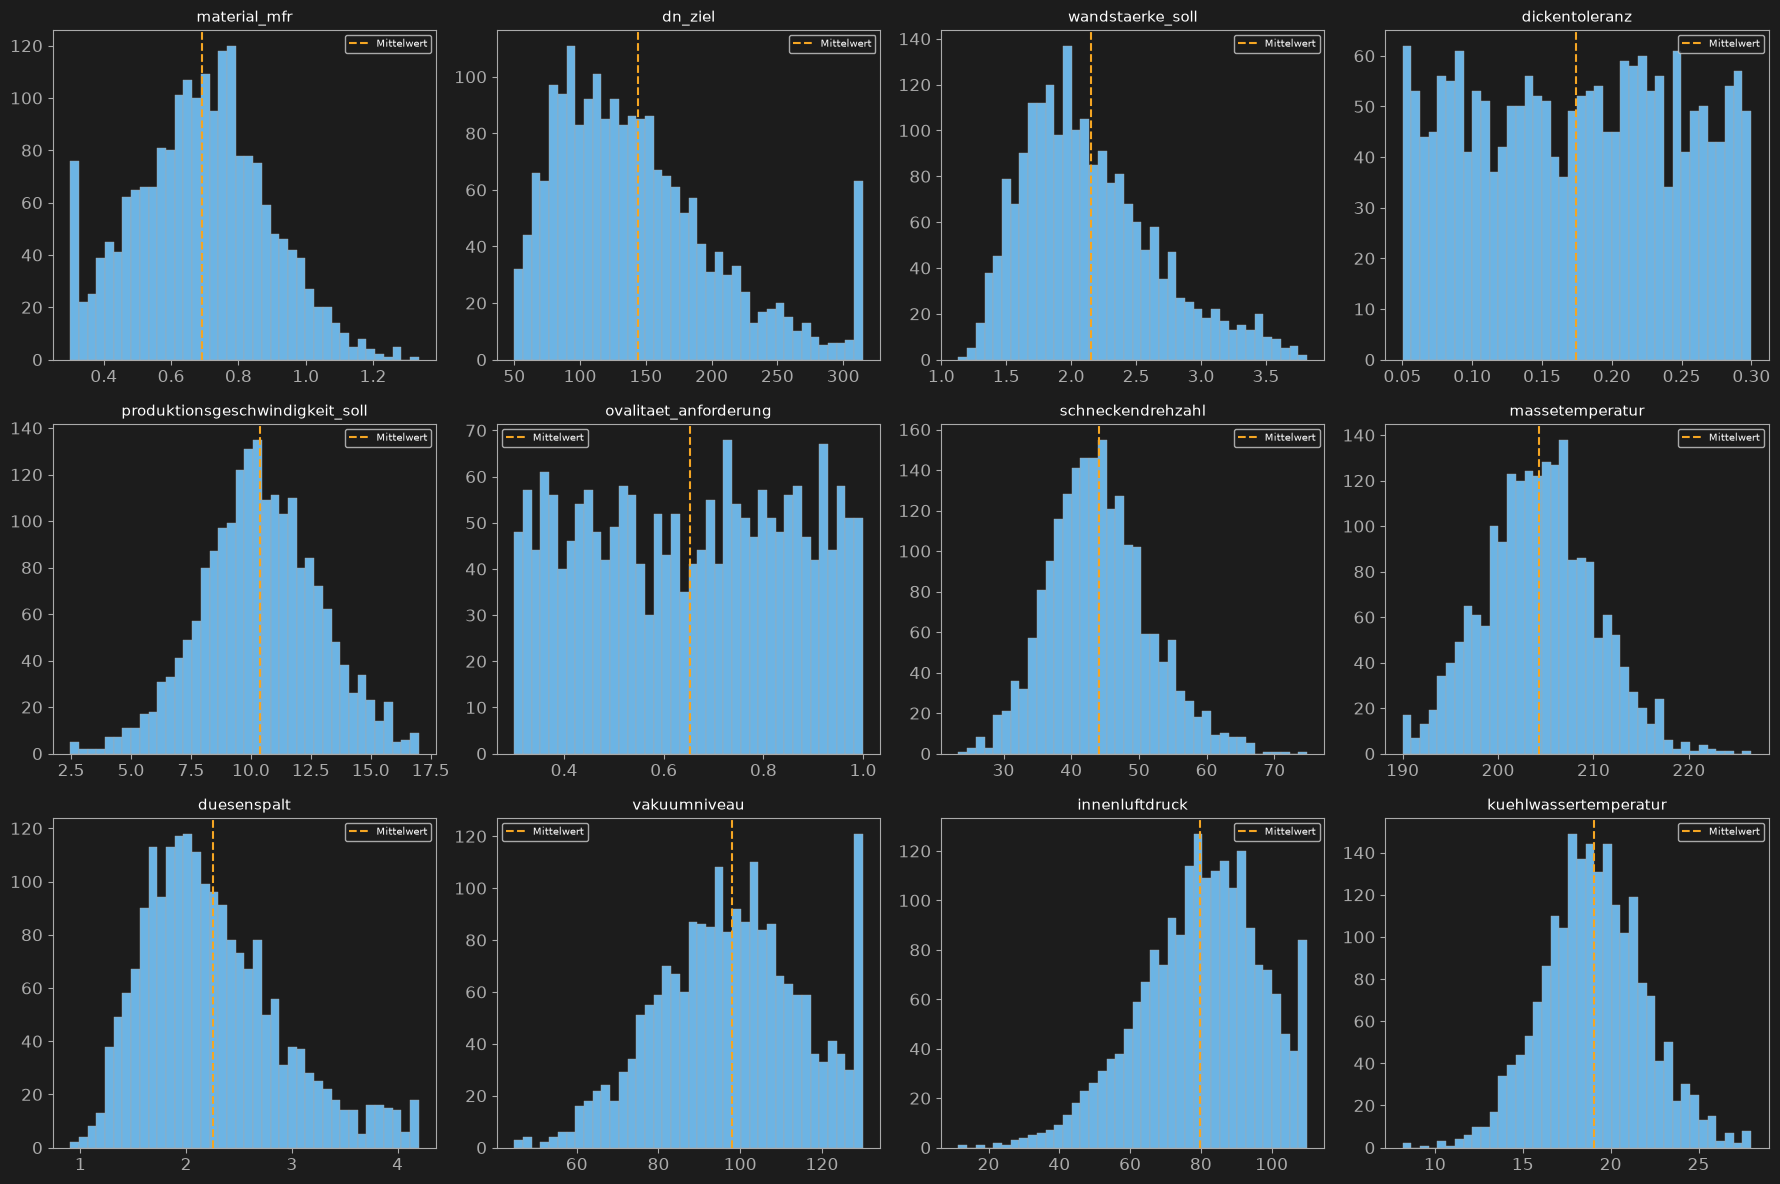

In [4]:
# =============================================================================
# Zelle 03 – Verteilungs-Histogramme aller numerischen X_B/Y_B-Merkmale
# =============================================================================
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for ax, col in zip(axes, numerische_merkmale):
    ax.hist(df_b[col], bins=40, color=COLOR_BLUE, edgecolor=COLOR_TEXT_MUTED, linewidth=0.3)
    ax.axvline(df_b[col].mean(), color=COLOR_GOLD, linestyle="--", linewidth=1.5, label="Mittelwert")
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=7)

# Leere Subplots ausblenden (12 Slots, 11 Merkmale)
for ax in axes[len(numerische_merkmale):]:
    ax.axis("off")

plt.tight_layout()
save_figure(fig, "../reports/figures/09_verteilungen_model_b.png")
plt.show()

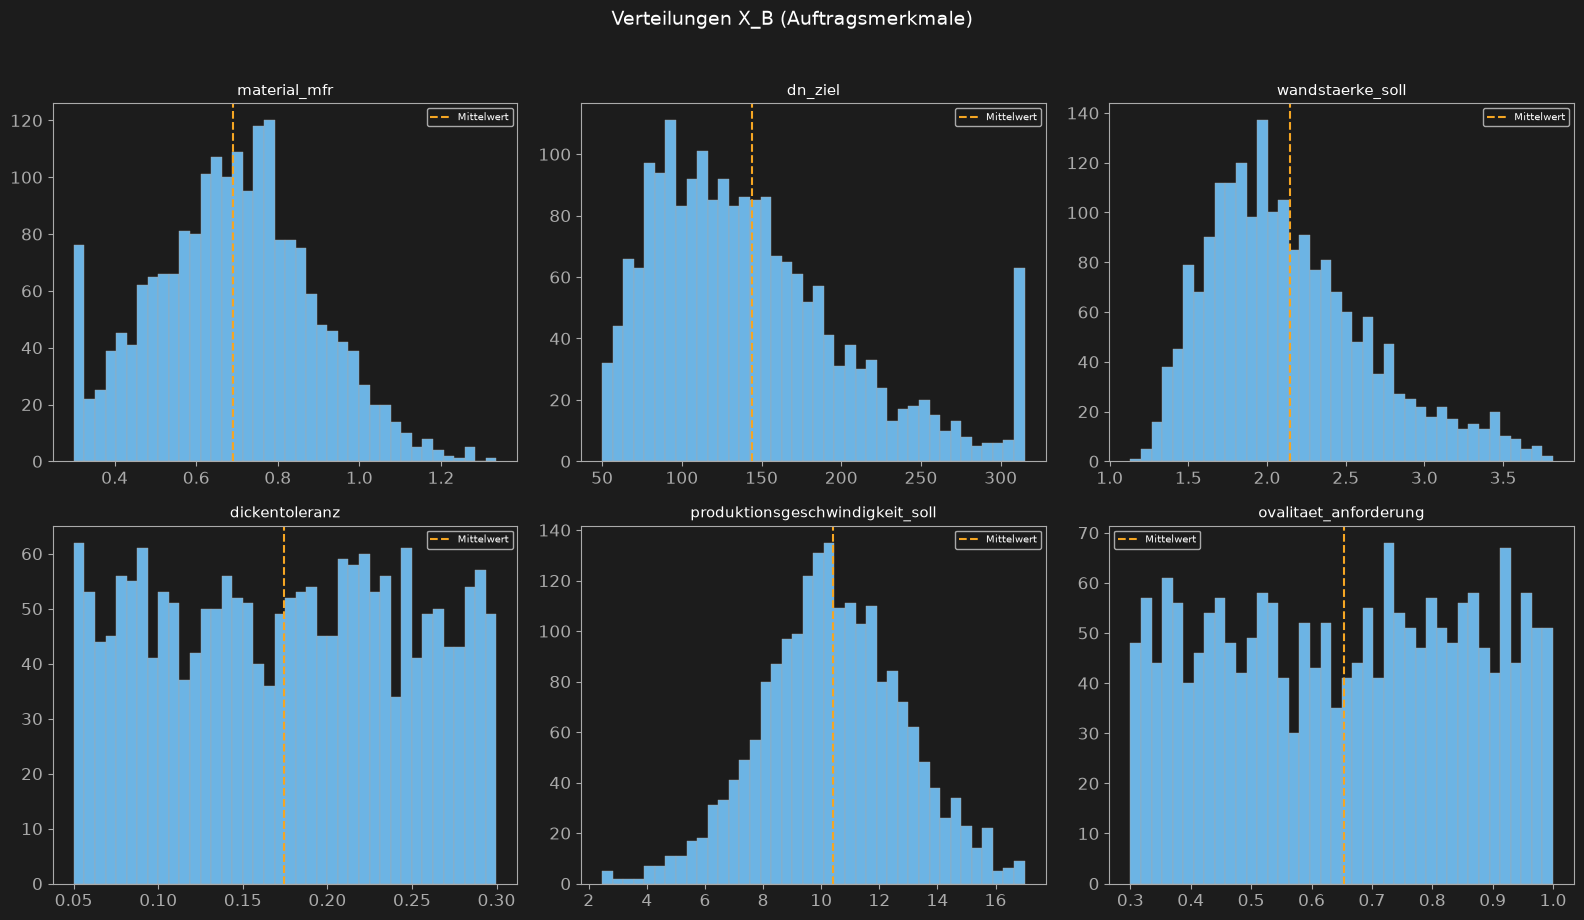

In [5]:
# =============================================================================
# Zelle 03a – Verteilungs-Histogramme X_B (Auftragsmerkmale)
# =============================================================================
x_b_numerisch = [c for c in X_B_MERKMALE if c != "wandtyp"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, x_b_numerisch):
    ax.hist(df_b[col], bins=40, color=COLOR_BLUE, edgecolor=COLOR_TEXT_MUTED, linewidth=0.3)
    ax.axvline(df_b[col].mean(), color=COLOR_GOLD, linestyle="--", linewidth=1.5, label="Mittelwert")
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=7)

for ax in axes[len(x_b_numerisch):]:
    ax.axis("off")

fig.suptitle("Verteilungen X_B (Auftragsmerkmale)", fontsize=14, y=1.02)
plt.tight_layout()
save_figure(fig, "../reports/figures/09_verteilungen_x_b.png")
plt.show()

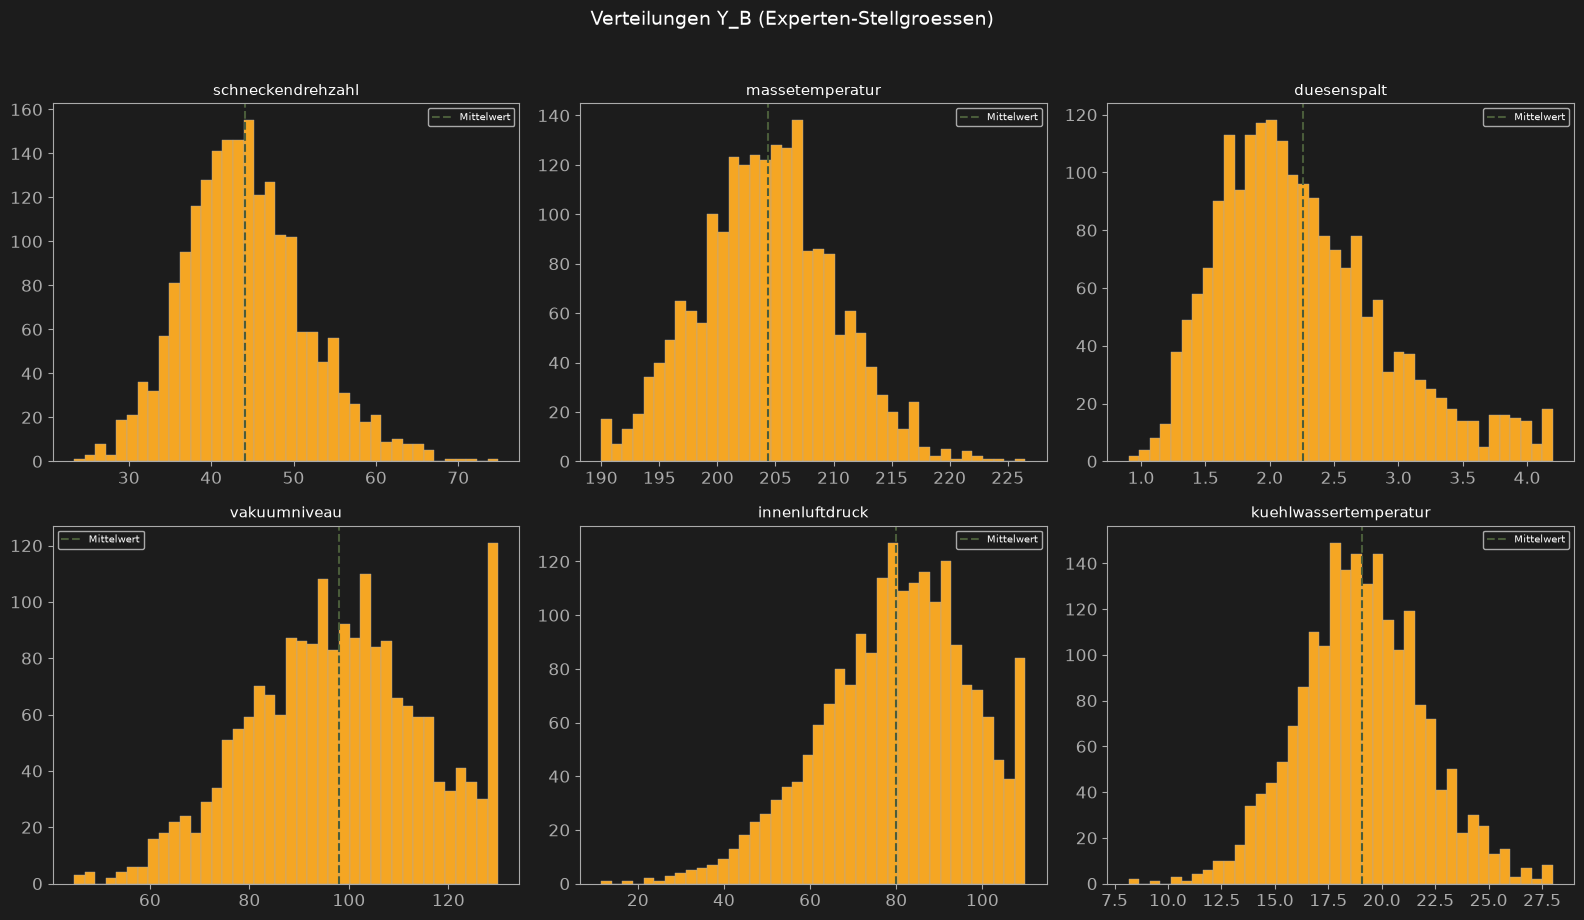

In [6]:
# =============================================================================
# Zelle 03b – Verteilungs-Histogramme Y_B (Experten-Stellgroessen)
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, Y_B_MERKMALE):
    ax.hist(df_b[col], bins=40, color=COLOR_GOLD, edgecolor=COLOR_TEXT_MUTED, linewidth=0.3)
    ax.axvline(df_b[col].mean(), color=COLOR_GREEN, linestyle="--", linewidth=1.5, label="Mittelwert")
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=7)

for ax in axes[len(Y_B_MERKMALE):]:
    ax.axis("off")

fig.suptitle("Verteilungen Y_B (Experten-Stellgroessen)", fontsize=14, y=1.02)
plt.tight_layout()
save_figure(fig, "../reports/figures/09_verteilungen_y_b.png")
plt.show()

## Datenwörterbuch – Modell B (model_b_raw.csv), aktualisiert nach Vakuum/Innenluft-Korrektur

| Spalte | Beschreibung | Einheit | Typ |
|---|---|---|---|
| material_mfr | Schmelzindex der Materialcharge | g/10min | kontinuierlich |
| dn_ziel | Ziel-Nennweite des Rohrs | mm | kontinuierlich |
| wandstaerke_soll | Geforderte Wandstärke | mm | kontinuierlich |
| dickentoleranz | Zulässige Abweichung von der Sollwandstärke | mm | kontinuierlich |
| wandtyp | Rohrkonstruktion | – | kategorial (einwandig/doppelwandig) |
| produktionsgeschwindigkeit_soll | Geforderte Produktionsgeschwindigkeit | m/min | kontinuierlich |
| ovalitaet_anforderung | Zulässige Rundheitsabweichung | % | kontinuierlich |
| schneckendrehzahl | Gewählte Schneckendrehzahl | U/min | kontinuierlich, **Zielgröße (Y_B)** |
| massetemperatur | Gewählte Massetemperatur | °C | kontinuierlich, **Zielgröße (Y_B)** |
| duesenspalt | Gewählter Düsenspalt | mm | kontinuierlich, **Zielgröße (Y_B)** |
| **vakuumniveau** | Gewähltes Vakuumniveau (zieht Schmelzschlauch an Kavität) | mbar | kontinuierlich, **Zielgröße (Y_B)**, **neu** |
| **innenluftdruck** | Gewählter Innenluftdruck (stabilisiert Schmelzschlauch gegen Kollaps) | mbar | kontinuierlich, **Zielgröße (Y_B)**, **neu** |
| kuehlwassertemperatur | Gewählte Kühlwassertemperatur | °C | kontinuierlich, **Zielgröße (Y_B)** |
| schmelzfestigkeit_proxy | Aus MFR abgeleiteter Hilfsindikator (Konstruktionsgröße, kein echtes X_B/Y_B) | – | kontinuierlich, Hilfsvariable |

**X_B (7 Eingabemerkmale):** unverändert

**Y_B (6 Zielgrößen, geändert):** schneckendrehzahl, massetemperatur, duesenspalt, **vakuumniveau, innenluftdruck** (ersetzen kalibrierdruck), kuehlwassertemperatur

**Entfernt:** kalibrierdruck, kalibriermechanismus (fachlich unrealistischer harter DN-Schwellenwert-Schalter, siehe Notebook 08 Korrektur)

In [7]:
# =============================================================================
# Zelle 06 – AP 0.1: Blinde erste Sichtung (wie ein Analyst ohne Vorwissen)
# =============================================================================
print(f"Shape: {df_b.shape}")
print(f"\nSpalten:\n{df_b.columns.tolist()}")
print(f"\nDatentypen:\n{df_b.dtypes}")
df_b.head()

Shape: (2000, 14)

Spalten:
['material_mfr', 'dn_ziel', 'wandstaerke_soll', 'dickentoleranz', 'wandtyp', 'produktionsgeschwindigkeit_soll', 'ovalitaet_anforderung', 'schneckendrehzahl', 'massetemperatur', 'duesenspalt', 'vakuumniveau', 'innenluftdruck', 'kuehlwassertemperatur', 'schmelzfestigkeit_proxy']

Datentypen:
material_mfr                       float64
dn_ziel                            float64
wandstaerke_soll                   float64
dickentoleranz                     float64
wandtyp                             object
produktionsgeschwindigkeit_soll    float64
ovalitaet_anforderung              float64
schneckendrehzahl                  float64
massetemperatur                    float64
duesenspalt                        float64
vakuumniveau                       float64
innenluftdruck                     float64
kuehlwassertemperatur              float64
schmelzfestigkeit_proxy            float64
dtype: object


,material_mfr,dn_ziel,wandstaerke_soll,dickentoleranz,wandtyp,produktionsgeschwindigkeit_soll,ovalitaet_anforderung,schneckendrehzahl,massetemperatur,duesenspalt,vakuumniveau,innenluftdruck,kuehlwassertemperatur,schmelzfestigkeit_proxy
0,0.760943,104.164565,1.385443,0.055494,einwandig,9.400096,0.441754,33.691143,200.906186,1.434323,90.219856,78.197271,19.783884,0.539057
1,0.492003,158.608859,2.350657,0.295226,doppelwandig,10.168837,0.353945,43.847410,199.855728,2.346622,104.351909,62.177159,19.459041,0.807997
2,0.850090,123.340827,1.836205,0.114787,einwandig,10.907655,0.784632,45.499866,210.933172,1.929061,88.222130,105.947346,16.953516,0.449910
3,0.888113,225.335978,2.589429,0.198277,einwandig,6.963402,0.734473,46.943818,208.291018,2.655661,104.679660,57.771840,21.110659,0.411887
4,0.309793,72.773106,1.553914,0.125063,einwandig,12.279022,0.882630,36.970557,190.000000,1.597350,89.855192,91.287064,19.647650,0.990207


In [8]:
# =============================================================================
# Zelle 07 – AP 1.3 + 1.4: Fehlende Werte-Check + IQR-Ausreisser-Analyse
# =============================================================================
print("=== AP 1.3: Fehlende Werte ===")
print(df_b.isna().sum())
print(f"\nDatensatz bewusst vollstaendig gehalten (keine MCAR/MNAR-Luecken "
      f"generiert, im Gegensatz zu Modell A) - Entscheidung getroffen, um "
      f"Fokus auf die X_B->Y_B-Beziehung selbst zu legen.")

print("\n=== AP 1.4: IQR-Ausreisser je numerischer Variable ===")
numerische_merkmale = [c for c in df_b.columns if df_b[c].dtype != "object"]

ausreisser_ergebnisse = []
for col in numerische_merkmale:
    q1, q3 = df_b[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    untere_grenze, obere_grenze = q1 - 1.5*iqr, q3 + 1.5*iqr
    ausreisser = df_b[(df_b[col] < untere_grenze) | (df_b[col] > obere_grenze)]
    ausreisser_ergebnisse.append({
        "merkmal": col, "q1": round(q1,3), "q3": round(q3,3), "iqr": round(iqr,3),
        "untere_grenze": round(untere_grenze,3), "obere_grenze": round(obere_grenze,3),
        "n_ausreisser": len(ausreisser), "anteil_prozent": round(len(ausreisser)/len(df_b)*100, 2)
    })

ausreisser_df = pd.DataFrame(ausreisser_ergebnisse)
print(ausreisser_df.to_string(index=False))
ausreisser_df.to_csv("../reports/tables/09_iqr_ausreisser_model_b.csv", index=False)
print("\nGespeichert: reports/tables/09_iqr_ausreisser_model_b.csv")

=== AP 1.3: Fehlende Werte ===
material_mfr                       0
dn_ziel                            0
wandstaerke_soll                   0
dickentoleranz                     0
wandtyp                            0
produktionsgeschwindigkeit_soll    0
ovalitaet_anforderung              0
schneckendrehzahl                  0
massetemperatur                    0
duesenspalt                        0
vakuumniveau                       0
innenluftdruck                     0
kuehlwassertemperatur              0
schmelzfestigkeit_proxy            0
dtype: int64

Datensatz bewusst vollstaendig gehalten (keine MCAR/MNAR-Luecken generiert, im Gegensatz zu Modell A) - Entscheidung getroffen, um Fokus auf die X_B->Y_B-Beziehung selbst zu legen.

=== AP 1.4: IQR-Ausreisser je numerischer Variable ===
                        merkmal      q1      q3    iqr  untere_grenze  obere_grenze  n_ausreisser  anteil_prozent
                   material_mfr   0.556   0.820  0.264          0.160         1.216   

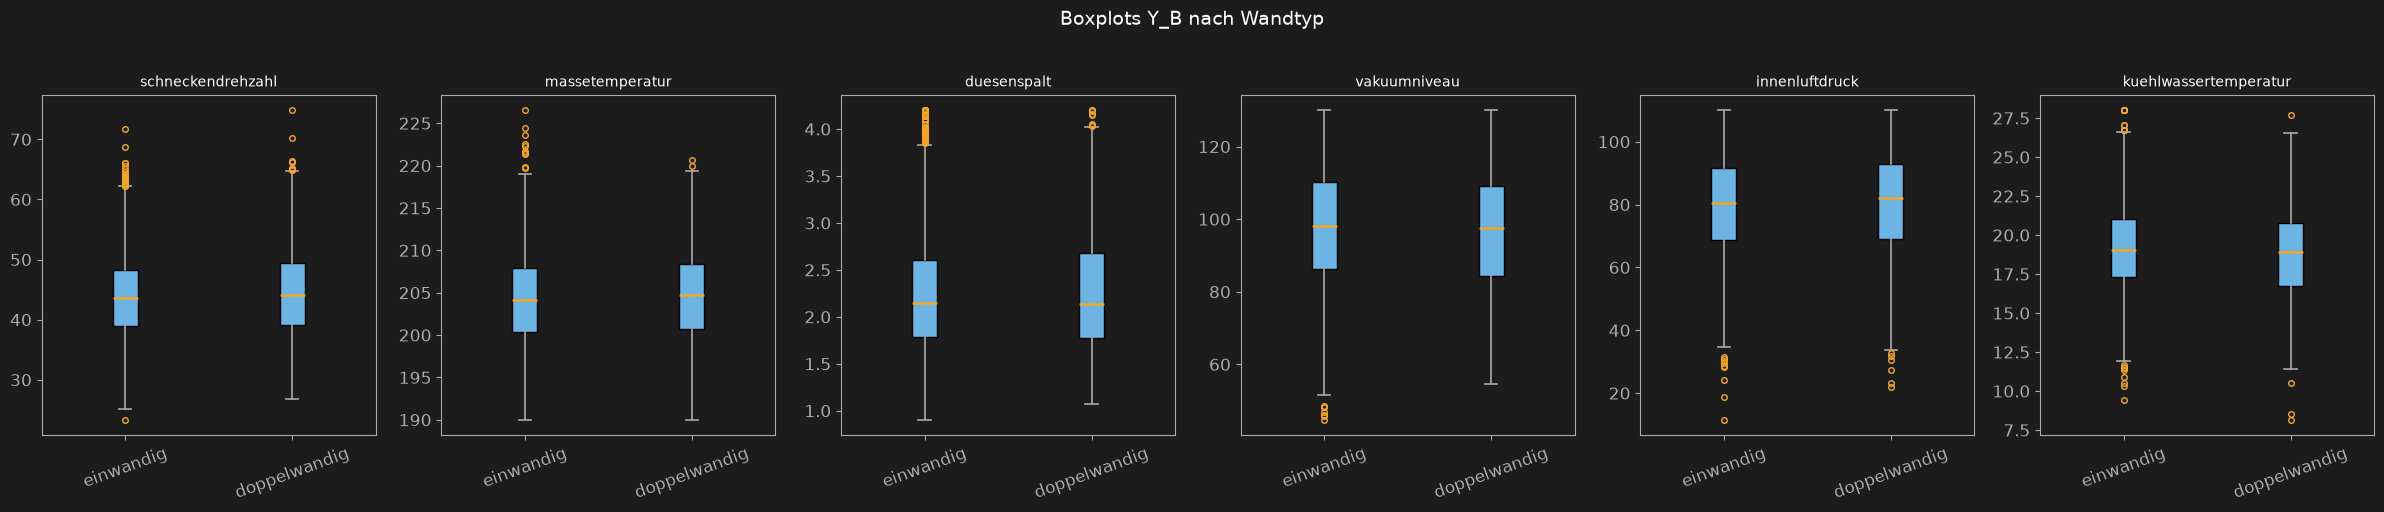

In [9]:
# =============================================================================
# Zelle 08 – AP 2.5: Boxplots Y_B nach Wandtyp
# =============================================================================
# KORREKTUR: "nach Mechanismus"-Zeile entfaellt komplett - kalibriermechanismus
# existiert nicht mehr (siehe Notebook 08 Korrektur: Vakuum/Innenluft sind
# jetzt zwei separate, gleichzeitig wirkende kontinuierliche Groessen statt
# einer kategorialen Schalter-Variable). Grafik auf 6 Y_B-Spalten erweitert.
# =============================================================================

fig, axes = plt.subplots(1, 6, figsize=(24, 5))

for i, y_col in enumerate(Y_B_MERKMALE):
    daten_wandtyp = [df_b[df_b["wandtyp"]==w][y_col].values for w in ["einwandig", "doppelwandig"]]
    bp1 = axes[i].boxplot(daten_wandtyp, tick_labels=["einwandig","doppelwandig"], patch_artist=True, **BOXPLOT_STYLE)
    for box in bp1["boxes"]:
        box.set_facecolor(COLOR_BLUE)
    axes[i].set_title(y_col, fontsize=10)
    axes[i].tick_params(axis="x", rotation=20)

fig.suptitle("Boxplots Y_B nach Wandtyp", fontsize=14, y=1.02)
plt.tight_layout()
save_figure(fig, "../reports/figures/09_boxplots_y_b_nach_wandtyp.png")
plt.show()

In [10]:
# =============================================================================
# Zelle 09 – AP 2.1: Pearson-Korrelationsmatrix berechnen (X_B numerisch x Y_B)
# =============================================================================
x_b_numerisch = ["material_mfr", "dn_ziel", "wandstaerke_soll", "dickentoleranz",
                  "produktionsgeschwindigkeit_soll", "ovalitaet_anforderung"]
pearson_matrix = pd.DataFrame(index=x_b_numerisch, columns=Y_B_MERKMALE, dtype=float)
for x_col in x_b_numerisch:
    for y_col in Y_B_MERKMALE:
        pearson_matrix.loc[x_col, y_col] = df_b[x_col].corr(df_b[y_col], method="pearson")
print(pearson_matrix.round(3).to_string())
pearson_matrix.to_csv("../reports/tables/09_pearson_korrelation_x_b_y_b.csv")

                                 schneckendrehzahl  massetemperatur  duesenspalt  vakuumniveau  innenluftdruck  kuehlwassertemperatur
material_mfr                                -0.056            0.352       -0.109        -0.237           0.187                 -0.177
dn_ziel                                      0.740            0.548        0.943         0.528          -0.636                 -0.081
wandstaerke_soll                             0.709            0.534        0.972         0.535          -0.637                 -0.079
dickentoleranz                               0.002           -0.021       -0.025         0.032           0.051                 -0.021
produktionsgeschwindigkeit_soll              0.141           -0.079       -0.419        -0.242           0.553                 -0.397
ovalitaet_anforderung                        0.006           -0.034        0.014        -0.196          -0.005                 -0.004


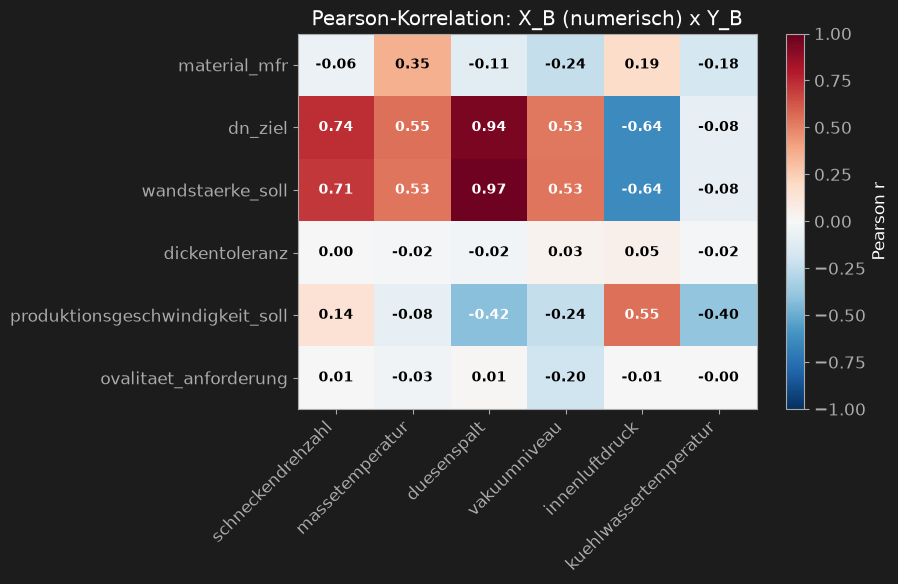

In [11]:
# =============================================================================
# Zelle 09b – AP 2.1: Pearson-Korrelation Heatmap (Textfarbe je nach Zellwert)
# =============================================================================
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(pearson_matrix.values.astype(float), cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(Y_B_MERKMALE)))
ax.set_xticklabels(Y_B_MERKMALE, rotation=45, ha="right")
ax.set_yticks(range(len(x_b_numerisch)))
ax.set_yticklabels(x_b_numerisch)
for i in range(len(x_b_numerisch)):
    for j in range(len(Y_B_MERKMALE)):
        wert = pearson_matrix.values[i, j]
        textfarbe = "black" if abs(wert) < 0.4 else "white"
        ax.text(j, i, f"{wert:.2f}", ha="center", va="center", color=textfarbe, fontsize=10, fontweight="bold")
plt.colorbar(im, label="Pearson r")
plt.title("Pearson-Korrelation: X_B (numerisch) x Y_B")
plt.tight_layout()
save_figure(fig, "../reports/figures/09_pearson_heatmap_x_b_y_b.png")
plt.show()

                                 schneckendrehzahl  massetemperatur  duesenspalt  vakuumniveau  innenluftdruck  kuehlwassertemperatur
material_mfr                                -0.045            0.337       -0.106        -0.237           0.183                 -0.177
dn_ziel                                      0.695            0.521        0.924         0.505          -0.585                 -0.074
wandstaerke_soll                             0.662            0.510        0.965         0.514          -0.590                 -0.076
dickentoleranz                               0.009           -0.019       -0.021         0.029           0.047                 -0.029
produktionsgeschwindigkeit_soll              0.151           -0.081       -0.391        -0.231           0.532                 -0.371
ovalitaet_anforderung                        0.009           -0.031        0.009        -0.194          -0.001                 -0.003


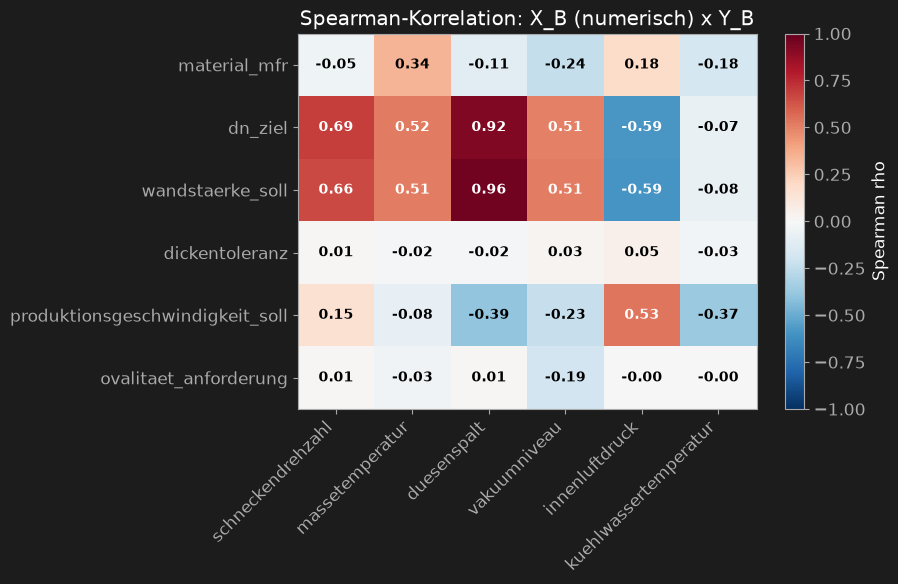


=== Groesste Abweichungen Pearson vs. Spearman (Hinweis auf Nichtlinearitaet) ===
dn_ziel                          innenluftdruck       0.050711
wandstaerke_soll                 schneckendrehzahl    0.047379
                                 innenluftdruck       0.046806
dn_ziel                          schneckendrehzahl    0.044803
produktionsgeschwindigkeit_soll  duesenspalt          0.027424
dtype: float64


In [12]:
# =============================================================================
# Zelle 10 – AP 2.2: Spearman-Korrelationsmatrix (X_B numerisch x Y_B)
# =============================================================================
# Ergaenzt Pearson (nur lineare Zusammenhaenge) um monotone, auch
# nichtlineare Beziehungen - relevant v.a. fuer kalibrierdruck, wo der
# Formluft/Vakuum-Sprung vermutlich von Spearman staerker erfasst wird.
# =============================================================================

spearman_matrix = pd.DataFrame(index=x_b_numerisch, columns=Y_B_MERKMALE, dtype=float)
for x_col in x_b_numerisch:
    for y_col in Y_B_MERKMALE:
        spearman_matrix.loc[x_col, y_col] = df_b[x_col].corr(df_b[y_col], method="spearman")

print(spearman_matrix.round(3).to_string())
spearman_matrix.to_csv("../reports/tables/09_spearman_korrelation_x_b_y_b.csv")

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(spearman_matrix.values.astype(float), cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(Y_B_MERKMALE)))
ax.set_xticklabels(Y_B_MERKMALE, rotation=45, ha="right")
ax.set_yticks(range(len(x_b_numerisch)))
ax.set_yticklabels(x_b_numerisch)
for i in range(len(x_b_numerisch)):
    for j in range(len(Y_B_MERKMALE)):
        wert = spearman_matrix.values[i, j]
        textfarbe = "black" if abs(wert) < 0.4 else "white"
        ax.text(j, i, f"{wert:.2f}", ha="center", va="center", color=textfarbe, fontsize=10, fontweight="bold")
plt.colorbar(im, label="Spearman rho")
plt.title("Spearman-Korrelation: X_B (numerisch) x Y_B")
plt.tight_layout()
save_figure(fig, "../reports/figures/09_spearman_heatmap_x_b_y_b.png")
plt.show()

# --- Direkter Vergleich Pearson vs. Spearman: wo weichen sie am staerksten ab? ---
differenz = (spearman_matrix.astype(float) - pearson_matrix.astype(float)).abs()
print("\n=== Groesste Abweichungen Pearson vs. Spearman (Hinweis auf Nichtlinearitaet) ===")
print(differenz.stack().sort_values(ascending=False).head(5))

                                 schneckendrehzahl  massetemperatur  duesenspalt  vakuumniveau  innenluftdruck  kuehlwassertemperatur
material_mfr                                 0.000            0.082        0.000         0.011           0.012                  0.025
dn_ziel                                      0.393            0.204        1.025         0.131           0.230                  0.042
wandstaerke_soll                             0.394            0.182        1.407         0.174           0.236                  0.013
dickentoleranz                               0.000            0.000        0.000         0.000           0.007                  0.000
produktionsgeschwindigkeit_soll              0.060            0.022        0.102         0.010           0.184                  0.091
ovalitaet_anforderung                        0.006            0.000        0.000         0.024           0.013                  0.000


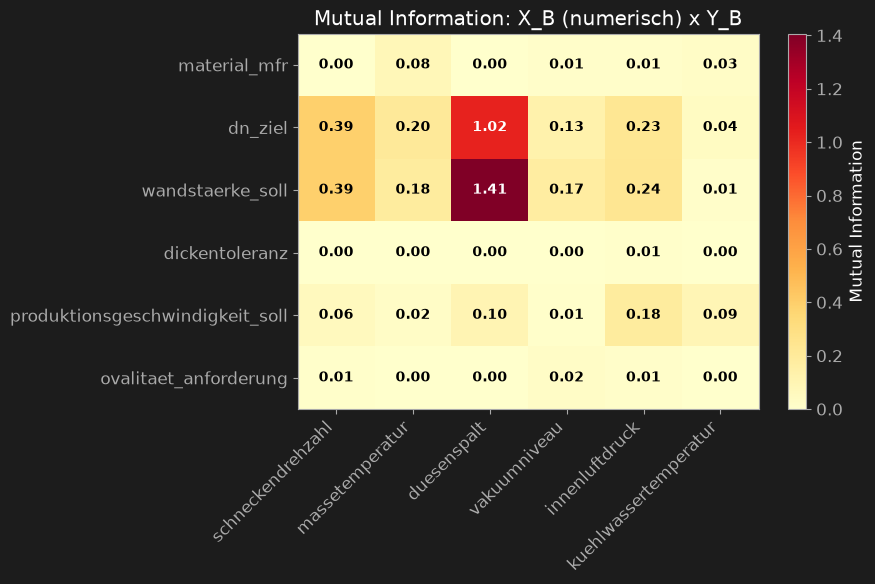


=== Vakuumniveau: Vergleich der drei Methoden ===
                                 pearson_abs  spearman_abs  mutual_info
material_mfr                           0.237         0.237        0.011
dn_ziel                                0.528         0.505        0.131
wandstaerke_soll                       0.535         0.514        0.174
dickentoleranz                         0.032         0.029        0.000
produktionsgeschwindigkeit_soll        0.242         0.231        0.010
ovalitaet_anforderung                  0.196         0.194        0.024

=== Innenluftdruck: Vergleich der drei Methoden ===
                                 pearson_abs  spearman_abs  mutual_info
material_mfr                           0.187         0.183        0.012
dn_ziel                                0.636         0.585        0.230
wandstaerke_soll                       0.637         0.590        0.236
dickentoleranz                         0.051         0.047        0.007
produktionsgeschwindigkeit_soll 

In [13]:
# =============================================================================
# Zelle 11 – AP 2.3: Mutual Information (X_B numerisch x Y_B)
# =============================================================================
# Erfasst beliebige statistische Abhaengigkeit, auch nicht-monotone
# Zusammenhaenge. KORREKTUR: alter Vergleichsblock referenzierte die nicht
# mehr existierende Spalte "kalibrierdruck" - ersetzt durch Vergleich fuer
# beide neuen Druckgroessen (vakuumniveau, innenluftdruck).
# =============================================================================
from sklearn.feature_selection import mutual_info_regression

mi_matrix = pd.DataFrame(index=x_b_numerisch, columns=Y_B_MERKMALE, dtype=float)
for y_col in Y_B_MERKMALE:
    mi_werte = mutual_info_regression(df_b[x_b_numerisch], df_b[y_col], random_state=SEED)
    mi_matrix[y_col] = mi_werte

print(mi_matrix.round(3).to_string())
mi_matrix.to_csv("../reports/tables/09_mutual_information_x_b_y_b.csv")

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(mi_matrix.values.astype(float), cmap="YlOrRd", vmin=0, aspect="auto")
ax.set_xticks(range(len(Y_B_MERKMALE)))
ax.set_xticklabels(Y_B_MERKMALE, rotation=45, ha="right")
ax.set_yticks(range(len(x_b_numerisch)))
ax.set_yticklabels(x_b_numerisch)
for i in range(len(x_b_numerisch)):
    for j in range(len(Y_B_MERKMALE)):
        wert = mi_matrix.values[i, j]
        textfarbe = "black" if wert < mi_matrix.values.max()*0.5 else "white"
        ax.text(j, i, f"{wert:.2f}", ha="center", va="center", color=textfarbe, fontsize=10, fontweight="bold")
plt.colorbar(im, label="Mutual Information")
plt.title("Mutual Information: X_B (numerisch) x Y_B")
plt.tight_layout()
save_figure(fig, "../reports/figures/09_mutual_information_heatmap.png")
plt.show()

# --- Vergleich: MI vs. Pearson/Spearman fuer vakuumniveau UND innenluftdruck ---
print("\n=== Vakuumniveau: Vergleich der drei Methoden ===")
vergleich_vakuum = pd.DataFrame({
    "pearson_abs": pearson_matrix["vakuumniveau"].astype(float).abs(),
    "spearman_abs": spearman_matrix["vakuumniveau"].astype(float).abs(),
    "mutual_info": mi_matrix["vakuumniveau"],
})
print(vergleich_vakuum.round(3).to_string())

print("\n=== Innenluftdruck: Vergleich der drei Methoden ===")
vergleich_innenluft = pd.DataFrame({
    "pearson_abs": pearson_matrix["innenluftdruck"].astype(float).abs(),
    "spearman_abs": spearman_matrix["innenluftdruck"].astype(float).abs(),
    "mutual_info": mi_matrix["innenluftdruck"],
})
print(vergleich_innenluft.round(3).to_string())

In [14]:
# =============================================================================
# Zelle 12 – AP 2.4: Kruskal-Wallis-Test (Wandtyp x Y_B)
# =============================================================================
# KORREKTUR: nur noch "wandtyp" als kategoriale Gruppierungsvariable -
# kalibriermechanismus existiert nicht mehr (Vakuum/Innenluft sind jetzt
# kontinuierliche, gleichzeitig wirkende Groessen, keine Kategorie).
# Formale statistische Absicherung der Boxplot-Beobachtungen aus Zelle 08.
# =============================================================================
kw_ergebnisse = []
gruppen_werte = df_b["wandtyp"].unique()
for y_col in Y_B_MERKMALE:
    gruppen_daten = [df_b.loc[df_b["wandtyp"]==g, y_col].values for g in gruppen_werte]
    stat, p = stats.kruskal(*gruppen_daten)
    kw_ergebnisse.append({
        "gruppierung": "wandtyp", "y_merkmal": y_col,
        "h_statistik": round(stat, 2), "p_wert": round(p, 5), "signifikant": p < 0.05
    })

kw_df = pd.DataFrame(kw_ergebnisse)
print(kw_df.to_string(index=False))
kw_df.to_csv("../reports/tables/09_kruskal_wallis_model_b.csv", index=False)

gruppierung             y_merkmal  h_statistik  p_wert  signifikant
    wandtyp     schneckendrehzahl         4.57 0.03261         True
    wandtyp       massetemperatur         1.77 0.18389        False
    wandtyp           duesenspalt         0.31 0.57554        False
    wandtyp          vakuumniveau         0.93 0.33384        False
    wandtyp        innenluftdruck         1.42 0.23266        False
    wandtyp kuehlwassertemperatur         3.43 0.06405        False


In [15]:
# =============================================================================
# Zelle 13 – AP 2.6: Einzelmerkmal-R² je X_B->Y_B-Paar (Lookup-Tabellen-Check)
# =============================================================================
# Beantwortet die urspruengliche Nutzerfrage: reicht ein einzelnes Merkmal
# (einfache lineare Regression) zur Vorhersage aus, oder braucht es
# mehrere Merkmale/nichtlineare Modelle fuer echten ML-Mehrwert?
# R² nahe 1.0 bei einem Einzelmerkmal = nahe an trivialem Lookup.
# =============================================================================
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

r2_matrix = pd.DataFrame(index=x_b_numerisch, columns=Y_B_MERKMALE, dtype=float)
for x_col in x_b_numerisch:
    for y_col in Y_B_MERKMALE:
        X_einzeln = df_b[[x_col]].values
        y_ziel = df_b[y_col].values
        modell = LinearRegression().fit(X_einzeln, y_ziel)
        r2_matrix.loc[x_col, y_col] = r2_score(y_ziel, modell.predict(X_einzeln))

print(r2_matrix.round(3).to_string())
r2_matrix.to_csv("../reports/tables/09_einzelmerkmal_r2_model_b.csv")

# --- Bestes Einzelmerkmal je Y_B, zur Interpretation ---
print("\n=== Bestes einzelnes X_B-Merkmal je Y_B (nach R²) ===")
for y_col in Y_B_MERKMALE:
    bestes_merkmal = r2_matrix[y_col].astype(float).idxmax()
    bester_r2 = r2_matrix[y_col].astype(float).max()
    einordnung = "nahe Lookup" if bester_r2 > 0.85 else ("moderat erklaerbar" if bester_r2 > 0.4 else "schwach, ML-Mehrwert noetig")
    print(f"  {y_col:22s} <- {bestes_merkmal:25s} (R²={bester_r2:.3f}, {einordnung})")

                                 schneckendrehzahl  massetemperatur  duesenspalt  vakuumniveau  innenluftdruck  kuehlwassertemperatur
material_mfr                                 0.003            0.124        0.012         0.056           0.035                  0.031
dn_ziel                                      0.547            0.300        0.889         0.279           0.405                  0.007
wandstaerke_soll                             0.503            0.285        0.945         0.286           0.405                  0.006
dickentoleranz                               0.000            0.000        0.001         0.001           0.003                  0.000
produktionsgeschwindigkeit_soll              0.020            0.006        0.175         0.059           0.306                  0.157
ovalitaet_anforderung                        0.000            0.001        0.000         0.038           0.000                  0.000

=== Bestes einzelnes X_B-Merkmal je Y_B (nach R²) ===
  schne

                                 schneckendrehzahl  massetemperatur  duesenspalt  vakuumniveau  innenluftdruck  kuehlwassertemperatur
material_mfr                                 0.023            0.231        0.011         0.157           0.103                  0.154
dn_ziel                                      0.582            0.259        0.011         0.142           0.293                  0.153
wandstaerke_soll                             0.074            0.224        0.954         0.354           0.254                  0.137
dickentoleranz                               0.025            0.077        0.009         0.089           0.076                  0.124
produktionsgeschwindigkeit_soll              0.267            0.120        0.007         0.095           0.192                  0.302
ovalitaet_anforderung                        0.026            0.081        0.007         0.151           0.074                  0.116
wandtyp_einwandig                            0.003            

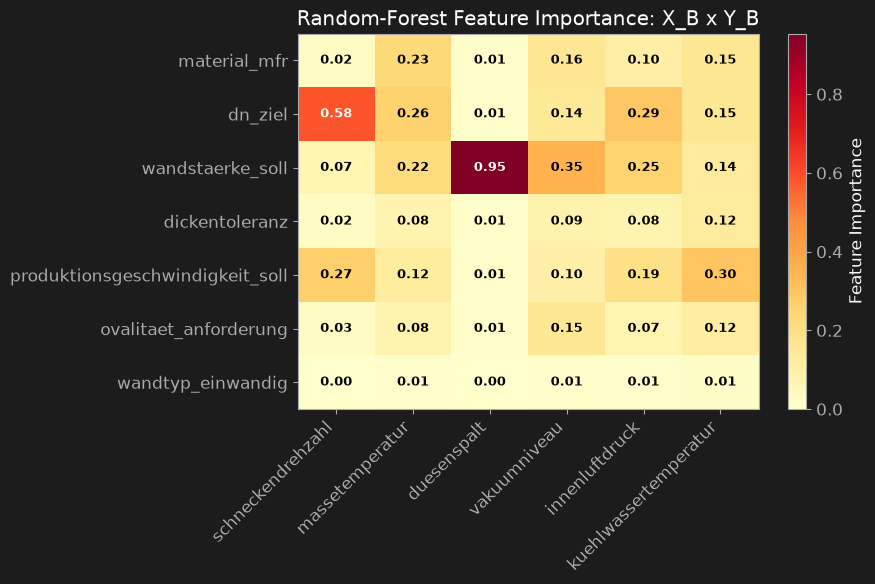

In [16]:
# =============================================================================
# Zelle 14 – AP 2.7: Feature Importance (Random-Forest-Baseline, alle X_B gleichzeitig)
# =============================================================================
# Ergaenzt den Einzelmerkmal-R²-Check (Zelle 13): beruecksichtigt
# Interaktionen zwischen mehreren X_B-Merkmalen gleichzeitig, inkl.
# kategorialer Merkmale (wandtyp, kalibriermechanismus als Dummies).
# =============================================================================
from sklearn.ensemble import RandomForestRegressor

X_B_ALLE = pd.get_dummies(df_b[X_B_MERKMALE], columns=["wandtyp"], drop_first=True)
# kalibriermechanismus bewusst NICHT hier, da er direkt aus dn_ziel abgeleitet
# ist (deterministische Funktion) - waere Leakage der eigenen Zielableitung
# in einigen Y_B-Formeln zu inkludieren; hier nur echte X_B-Auftragsmerkmale

importance_matrix = pd.DataFrame(index=X_B_ALLE.columns, columns=Y_B_MERKMALE, dtype=float)
for y_col in Y_B_MERKMALE:
    rf = RandomForestRegressor(n_estimators=200, random_state=SEED)
    rf.fit(X_B_ALLE, df_b[y_col])
    importance_matrix[y_col] = rf.feature_importances_

print(importance_matrix.round(3).to_string())
importance_matrix.to_csv("../reports/tables/09_feature_importance_rf_model_b.csv")

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(importance_matrix.values.astype(float), cmap="YlOrRd", vmin=0, aspect="auto")
ax.set_xticks(range(len(Y_B_MERKMALE)))
ax.set_xticklabels(Y_B_MERKMALE, rotation=45, ha="right")
ax.set_yticks(range(len(X_B_ALLE.columns)))
ax.set_yticklabels(X_B_ALLE.columns)
for i in range(len(X_B_ALLE.columns)):
    for j in range(len(Y_B_MERKMALE)):
        wert = importance_matrix.values[i, j]
        textfarbe = "black" if wert < importance_matrix.values.max()*0.5 else "white"
        ax.text(j, i, f"{wert:.2f}", ha="center", va="center", color=textfarbe, fontsize=9, fontweight="bold")
plt.colorbar(im, label="Feature Importance")
plt.title("Random-Forest Feature Importance: X_B x Y_B")
plt.tight_layout()
save_figure(fig, "../reports/figures/09_feature_importance_heatmap.png")
plt.show()

                                 material_mfr  dn_ziel  wandstaerke_soll  dickentoleranz  produktionsgeschwindigkeit_soll  ovalitaet_anforderung
material_mfr                            1.000   -0.055            -0.046          -0.002                           -0.000                 -0.029
dn_ziel                                -0.055    1.000             0.957          -0.027                           -0.454                  0.011
wandstaerke_soll                       -0.046    0.957             1.000          -0.023                           -0.437                  0.017
dickentoleranz                         -0.002   -0.027            -0.023           1.000                            0.043                 -0.022
produktionsgeschwindigkeit_soll        -0.000   -0.454            -0.437           0.043                            1.000                  0.013
ovalitaet_anforderung                  -0.029    0.011             0.017          -0.022                            0.013         

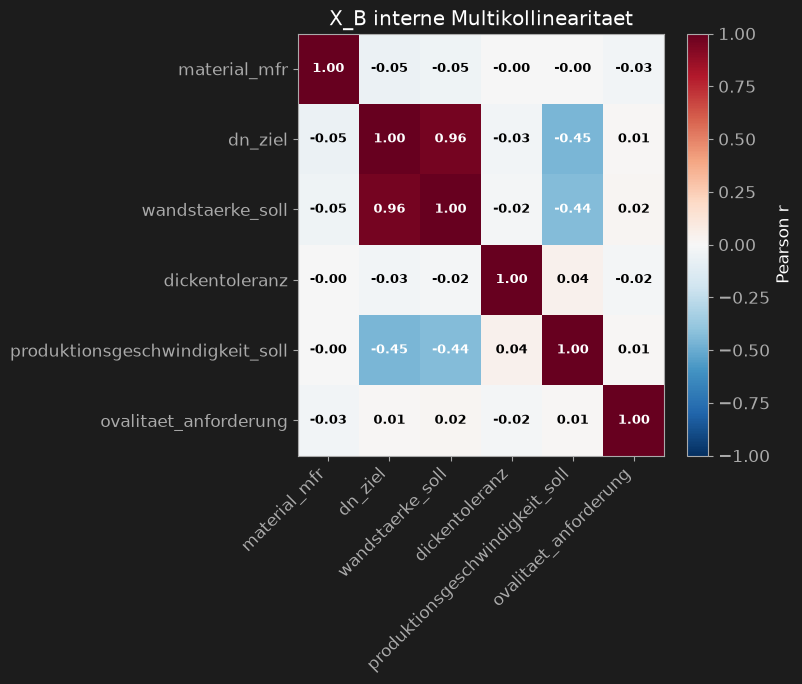


=== Auffaellig hohe Korrelationen (|r| > 0.5) ===
  dn_ziel <-> wandstaerke_soll: r=0.957


In [17]:
# =============================================================================
# Zelle 16 – AP 2.8: X_B interne Multikollinearitaet (nur numerische Merkmale)
# =============================================================================
# Relevant fuer spaetere Preprocessing-Entscheidungen: stark korrelierte
# X_B-Merkmale koennten bei linearen Modellen zu Instabilitaet fuehren
# (aehnlich dem Dummy-Variable-Trap-Prinzip aus Modell A), oder Redundanz
# aufzeigen, die Feature-Reduktion nahelegt.
# =============================================================================
x_b_korrelation = df_b[x_b_numerisch].corr(method="pearson")

print(x_b_korrelation.round(3).to_string())
x_b_korrelation.to_csv("../reports/tables/09_x_b_multikollinearitaet.csv")

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(x_b_korrelation.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(x_b_numerisch)))
ax.set_xticklabels(x_b_numerisch, rotation=45, ha="right")
ax.set_yticks(range(len(x_b_numerisch)))
ax.set_yticklabels(x_b_numerisch)
for i in range(len(x_b_numerisch)):
    for j in range(len(x_b_numerisch)):
        wert = x_b_korrelation.values[i, j]
        textfarbe = "black" if abs(wert) < 0.4 else "white"
        ax.text(j, i, f"{wert:.2f}", ha="center", va="center", color=textfarbe, fontsize=9, fontweight="bold")
plt.colorbar(im, label="Pearson r")
plt.title("X_B interne Multikollinearitaet")
plt.tight_layout()
save_figure(fig, "../reports/figures/09_x_b_multikollinearitaet_heatmap.png")
plt.show()

# --- Auffaellig hohe Paare markieren (|r| > 0.5, ausser Diagonale) ---
print("\n=== Auffaellig hohe Korrelationen (|r| > 0.5) ===")
for i in range(len(x_b_numerisch)):
    for j in range(i+1, len(x_b_numerisch)):
        r = x_b_korrelation.iloc[i, j]
        if abs(r) > 0.5:
            print(f"  {x_b_numerisch[i]} <-> {x_b_numerisch[j]}: r={r:.3f}")

=== Erklaerte Varianz je Hauptkomponente ===
  PC1:  37.9% (kumulativ:  37.9%)
  PC2:  17.2% (kumulativ:  55.1%)
  PC3:  16.8% (kumulativ:  71.9%)
  PC4:  16.0% (kumulativ:  87.9%)
  PC5:  11.4% (kumulativ:  99.3%)
  PC6:   0.7% (kumulativ: 100.0%)

=== Ladungen PC1 und PC2 ===
                                   PC1    PC2
material_mfr                    -0.050 -0.589
dn_ziel                          0.634 -0.007
wandstaerke_soll                 0.630 -0.008
dickentoleranz                  -0.040 -0.321
produktionsgeschwindigkeit_soll -0.443  0.091
ovalitaet_anforderung            0.011  0.736


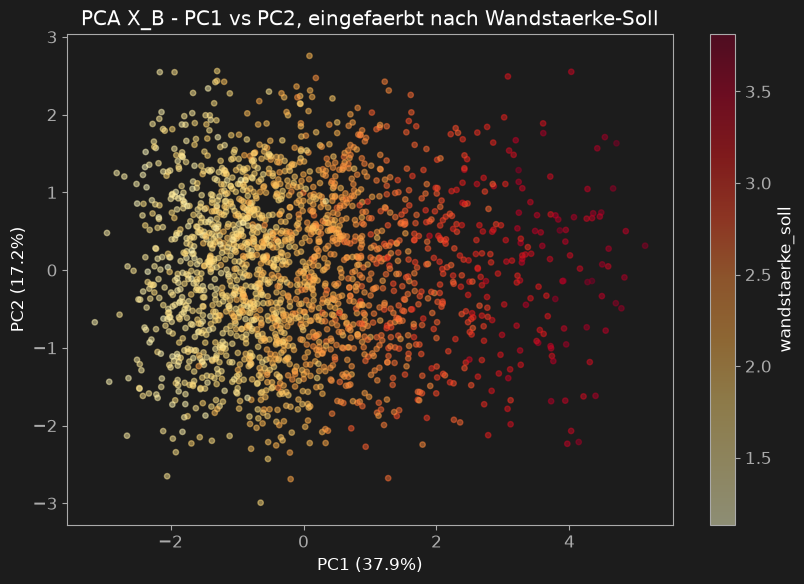

In [18]:
# =============================================================================
# Zelle 17 – AP 3: PCA auf X_B (numerisch, standardisiert)
# =============================================================================
# Prueft, ob wie bei Modell A ein dominanter "Baugroessen-Faktor" auftritt -
# angesichts der hohen dn_ziel<->wandstaerke_soll-Korrelation (Zelle 16)
# zu erwarten.
# =============================================================================
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_b_scaled = StandardScaler().fit_transform(df_b[x_b_numerisch])
pca_b = PCA(random_state=SEED)
X_b_pca = pca_b.fit_transform(X_b_scaled)

erklaerte_varianz = pca_b.explained_variance_ratio_
kumulativ = np.cumsum(erklaerte_varianz)

print("=== Erklaerte Varianz je Hauptkomponente ===")
for i, (ev, kum) in enumerate(zip(erklaerte_varianz, kumulativ)):
    print(f"  PC{i+1}: {ev*100:5.1f}% (kumulativ: {kum*100:5.1f}%)")

# --- Ladungen (Loadings) der ersten 2 Komponenten ---
loadings = pd.DataFrame(pca_b.components_[:2].T, index=x_b_numerisch, columns=["PC1", "PC2"])
print("\n=== Ladungen PC1 und PC2 ===")
print(loadings.round(3).to_string())
loadings.to_csv("../reports/tables/09_pca_ladungen_model_b.csv")

# --- Scatter PC1 vs PC2, eingefaerbt nach wandstaerke_soll (kontinuierlich) ---
# KORREKTUR: kalibriermechanismus existiert nicht mehr - Einfaerbung nach
# einer kontinuierlichen Groesse (staerkste PC1-Ladung) statt Kategorie.
fig, ax = plt.subplots(figsize=(8.5, 6))
scatter = ax.scatter(X_b_pca[:, 0], X_b_pca[:, 1], c=df_b["wandstaerke_soll"],
                     cmap="YlOrRd", alpha=0.5, s=15)
plt.colorbar(scatter, label="wandstaerke_soll")
ax.set_xlabel(f"PC1 ({erklaerte_varianz[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({erklaerte_varianz[1]*100:.1f}%)")
ax.set_title("PCA X_B - PC1 vs PC2, eingefaerbt nach Wandstaerke-Soll")
plt.tight_layout()
save_figure(fig, "../reports/figures/09_pca_scatter_model_b.png")
plt.show()

In [19]:
# =============================================================================
# Zelle 19 – AP 1.6: Kategoriale Variablen (Klassenbalance, Kardinalitaet, Entropie)
# =============================================================================
from scipy.stats import entropy

kategoriale_merkmale = ["wandtyp"]  # einzige verbleibende kategoriale X_B-Variable

kat_ergebnisse = []
for col in kategoriale_merkmale:
    verteilung = df_b[col].value_counts(normalize=True)
    kardinalitaet = df_b[col].nunique()
    shannon_entropie = entropy(verteilung, base=2)
    max_entropie = np.log2(kardinalitaet)
    normierte_entropie = shannon_entropie / max_entropie if max_entropie > 0 else 0

    kat_ergebnisse.append({
        "merkmal": col, "kardinalitaet": kardinalitaet,
        "dominante_klasse": verteilung.idxmax(), "dominanz_anteil": round(verteilung.max(), 3),
        "shannon_entropie_bit": round(shannon_entropie, 3),
        "max_entropie_bit": round(max_entropie, 3),
        "normierte_entropie": round(normierte_entropie, 3),
    })
    print(f"\n=== {col} ===")
    print(verteilung.round(3))

kat_df = pd.DataFrame(kat_ergebnisse)
print("\n=== Zusammenfassung ===")
print(kat_df.to_string(index=False))
kat_df.to_csv("../reports/tables/09_kategoriale_variablen_model_b.csv", index=False)


=== wandtyp ===
wandtyp
einwandig       0.738
doppelwandig    0.262
Name: proportion, dtype: float64

=== Zusammenfassung ===
merkmal  kardinalitaet dominante_klasse  dominanz_anteil  shannon_entropie_bit  max_entropie_bit  normierte_entropie
wandtyp              2        einwandig            0.738                  0.83               1.0                0.83


In [20]:
# =============================================================================
# Zelle 20 – AP 5: Bayes-Floor je Y_B-Groesse (Monte-Carlo, M=2000)
# =============================================================================
# Analog Notebook 03/Modell A: Rauschterme der eigenen Generierungsformeln
# wiederholt neu ziehen (X_B fixiert) - liefert die theoretisch erreichbare
# Obergrenze (R²) je Zielgroesse, unabhaengig vom spaeter verwendeten Modell.
# =============================================================================
M = 2000
rng_bayes = np.random.default_rng(777)
N_full = len(df_b)

material_mfr_ = df_b["material_mfr"].values
dn_ziel_ = df_b["dn_ziel"].values
wandstaerke_soll_ = df_b["wandstaerke_soll"].values
dickentoleranz_ = df_b["dickentoleranz"].values
produktionsgeschwindigkeit_soll_ = df_b["produktionsgeschwindigkeit_soll"].values
schmelzfestigkeit_proxy_ = df_b["schmelzfestigkeit_proxy"].values

sim_schneckendrehzahl = np.zeros((M, N_full))
sim_massetemperatur = np.zeros((M, N_full))
sim_duesenspalt = np.zeros((M, N_full))
sim_vakuumniveau = np.zeros((M, N_full))
sim_innenluftdruck = np.zeros((M, N_full))
sim_kuehlwasser = np.zeros((M, N_full))

for m in range(M):
    schneckendrehzahl_m = np.clip(
        8 + dn_ziel_ * 0.12 + produktionsgeschwindigkeit_soll_ * 1.8 + rng_bayes.normal(0, 3.0, N_full),
        10, 80)
    basis_temperatur = 190 + material_mfr_ * 12 + (dn_ziel_ / 315) * 10
    scherwaerme_zuschlag = (schneckendrehzahl_m - 40) * 0.30
    massetemperatur_m = np.clip(basis_temperatur + scherwaerme_zuschlag + rng_bayes.normal(0, 4.0, N_full), 190, 232)

    die_swell_basis = 0.95 + (material_mfr_ - 0.7) * 0.08
    duesenspalt_rauschen_staerke = 0.08 + dickentoleranz_ * 0.35
    duesenspalt_m = np.clip(
        (wandstaerke_soll_ / die_swell_basis) + (dn_ziel_ - 150) * 0.0015 + rng_bayes.normal(0, duesenspalt_rauschen_staerke, N_full),
        0.35, 4.2)

    vakuumniveau_m = np.clip(
        40 + wandstaerke_soll_ * 15 + schmelzfestigkeit_proxy_ * 20 + dn_ziel_ * 0.05 + rng_bayes.normal(0, 15, N_full),
        5, 130)
    innenluftdruck_m = np.clip(
        30 + (4.0 - wandstaerke_soll_) * 12 + produktionsgeschwindigkeit_soll_ * 2.5
        + (1.0 - schmelzfestigkeit_proxy_) * 15 - dn_ziel_ * 0.03 + rng_bayes.normal(0, 12, N_full),
        5, 110)

    kuehlwasser_m = np.clip(
        24 - (massetemperatur_m - 205) * 0.25 - produktionsgeschwindigkeit_soll_ * 0.5 + rng_bayes.normal(0, 2.2, N_full),
        5, 28)

    sim_schneckendrehzahl[m] = schneckendrehzahl_m
    sim_massetemperatur[m] = massetemperatur_m
    sim_duesenspalt[m] = duesenspalt_m
    sim_vakuumniveau[m] = vakuumniveau_m
    sim_innenluftdruck[m] = innenluftdruck_m
    sim_kuehlwasser[m] = kuehlwasser_m

bayes_ergebnisse = []
for name, sim in [("schneckendrehzahl", sim_schneckendrehzahl), ("massetemperatur", sim_massetemperatur),
                   ("duesenspalt", sim_duesenspalt), ("vakuumniveau", sim_vakuumniveau),
                   ("innenluftdruck", sim_innenluftdruck), ("kuehlwassertemperatur", sim_kuehlwasser)]:
    signal_je_zeile = sim.mean(axis=0)  # "wahrer" Erwartungswert je X_B-Kombination
    rausch_varianz = sim.var(axis=0).mean()  # mittlere Rauschvarianz um das Signal
    gesamt_varianz = df_b[name].var()
    bayes_r2 = 1 - (rausch_varianz / gesamt_varianz)
    bayes_ergebnisse.append({"y_merkmal": name, "bayes_r2_max": round(bayes_r2, 3),
                              "rausch_varianz": round(rausch_varianz, 3), "gesamt_varianz": round(gesamt_varianz, 3)})

bayes_df = pd.DataFrame(bayes_ergebnisse)
print(bayes_df.to_string(index=False))
bayes_df.to_csv("../reports/tables/09_bayes_floor_je_y_b.csv", index=False)

            y_merkmal  bayes_r2_max  rausch_varianz  gesamt_varianz
    schneckendrehzahl         0.834           8.992          54.256
      massetemperatur         0.506          16.612          33.622
          duesenspalt         0.952           0.020           0.423
         vakuumniveau         0.304         215.683         309.981
       innenluftdruck         0.531         136.401         290.837
kuehlwassertemperatur         0.307           5.871           8.466


In [21]:
# =============================================================================
# Zelle 21 – AP 6: Zusammenfassende Wichtigkeits-Tabelle (alle Methoden kombiniert)
# =============================================================================
# Konsolidiert Pearson (2.1), Spearman (2.2), Mutual Information (2.3),
# Einzelmerkmal-R² (2.6) und Random-Forest Feature Importance (2.7) in
# einer gemeinsamen Tabelle - robuste, mehrmethodische Entscheidungs-
# grundlage statt Verlass auf eine einzelne Methode.
# =============================================================================

zusammenfassung = []
for x_col in x_b_numerisch:
    for y_col in Y_B_MERKMALE:
        zusammenfassung.append({
            "x_merkmal": x_col, "y_merkmal": y_col,
            "pearson_abs": round(abs(pearson_matrix.loc[x_col, y_col]), 3),
            "spearman_abs": round(abs(spearman_matrix.loc[x_col, y_col]), 3),
            "mutual_info": round(mi_matrix.loc[x_col, y_col], 3),
            "einzelmerkmal_r2": round(r2_matrix.loc[x_col, y_col], 3),
            "rf_feature_importance": round(importance_matrix.loc[x_col, y_col], 3) if x_col in importance_matrix.index else None,
        })

zusammenfassung_df = pd.DataFrame(zusammenfassung)

# --- Rang-basierter Gesamtscore: Durchschnitt der Raenge ueber alle Methoden ---
# (robuster als direkter Wertevergleich, da Methoden unterschiedliche Skalen haben)
for spalte in ["pearson_abs", "spearman_abs", "mutual_info", "einzelmerkmal_r2", "rf_feature_importance"]:
    zusammenfassung_df[f"rang_{spalte}"] = zusammenfassung_df.groupby("y_merkmal")[spalte].rank(ascending=False)

rang_spalten = [c for c in zusammenfassung_df.columns if c.startswith("rang_")]
zusammenfassung_df["mittlerer_rang"] = zusammenfassung_df[rang_spalten].mean(axis=1)

zusammenfassung_df = zusammenfassung_df.sort_values(["y_merkmal", "mittlerer_rang"])
print(zusammenfassung_df[["x_merkmal", "y_merkmal", "pearson_abs", "spearman_abs",
                            "mutual_info", "einzelmerkmal_r2", "rf_feature_importance",
                            "mittlerer_rang"]].to_string(index=False))

zusammenfassung_df.to_csv("../reports/tables/09_zusammenfassende_wichtigkeit_model_b.csv", index=False)

# --- Top-Treiber je Y_B, nach mittlerem Rang ---
print("\n=== Staerkster Treiber je Y_B (niedrigster mittlerer Rang = staerkster Treiber) ===")
for y_col in Y_B_MERKMALE:
    sub = zusammenfassung_df[zusammenfassung_df["y_merkmal"]==y_col].sort_values("mittlerer_rang")
    top = sub.iloc[0]
    print(f"  {y_col:22s} <- {top['x_merkmal']:25s} (mittlerer Rang: {top['mittlerer_rang']:.1f})")

                      x_merkmal             y_merkmal  pearson_abs  spearman_abs  mutual_info  einzelmerkmal_r2  rf_feature_importance  mittlerer_rang
               wandstaerke_soll           duesenspalt        0.972         0.965        1.407             0.945                  0.954             1.0
                        dn_ziel           duesenspalt        0.943         0.924        1.025             0.889                  0.011             2.1
produktionsgeschwindigkeit_soll           duesenspalt        0.419         0.391        0.102             0.175                  0.007             3.5
                   material_mfr           duesenspalt        0.109         0.106        0.000             0.012                  0.011             3.9
                 dickentoleranz           duesenspalt        0.025         0.021        0.000             0.001                  0.009             4.8
          ovalitaet_anforderung           duesenspalt        0.014         0.009        0.000 

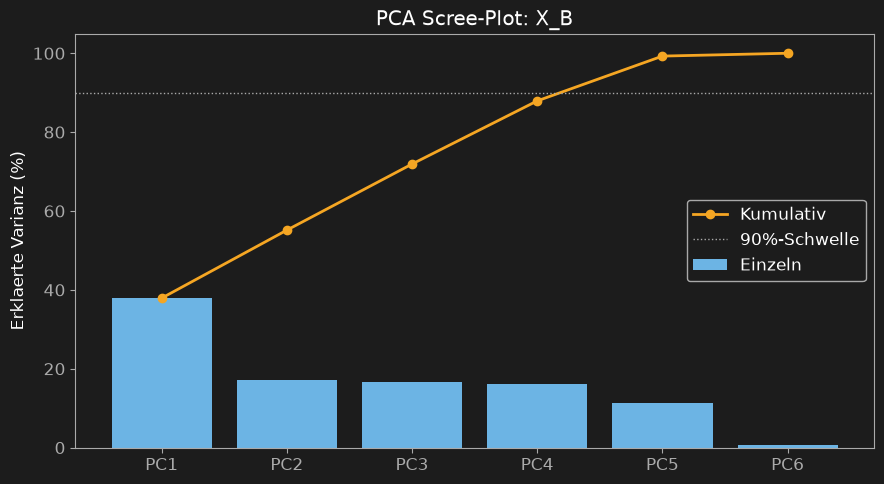

In [22]:
# =============================================================================
# Zelle 22a – Scree-Plot: erklaerte Varianz je PCA-Hauptkomponente
# =============================================================================
fig, ax = plt.subplots(figsize=(9, 5))
komponenten = [f"PC{i+1}" for i in range(len(erklaerte_varianz))]
ax.bar(komponenten, erklaerte_varianz*100, color=COLOR_BLUE, label="Einzeln")
ax.plot(komponenten, kumulativ*100, color=COLOR_GOLD, marker="o", linewidth=2, label="Kumulativ")
ax.axhline(90, color=COLOR_TEXT_MUTED, linestyle=":", linewidth=1, label="90%-Schwelle")
ax.set_ylabel("Erklaerte Varianz (%)")
ax.set_title("PCA Scree-Plot: X_B")
ax.legend()
plt.tight_layout()
save_figure(fig, "../reports/figures/09_pca_scree_plot.png")
plt.show()

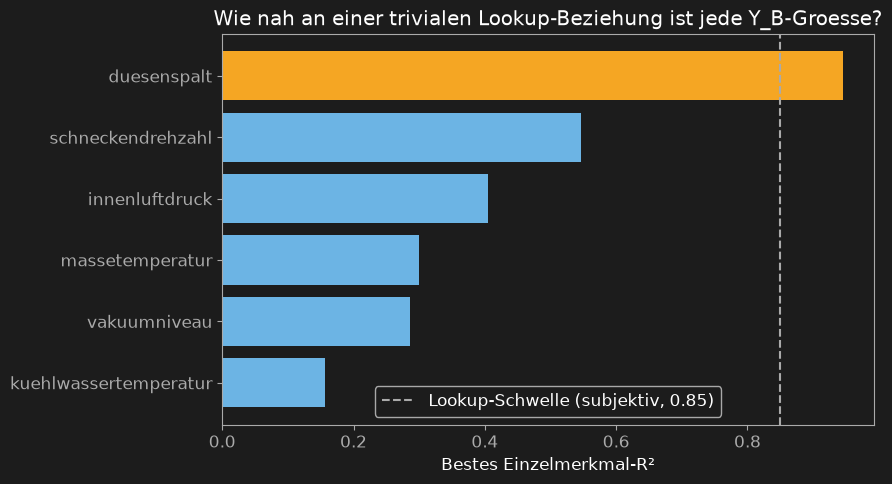

In [23]:
# =============================================================================
# Zelle 22b – Bestes Einzelmerkmal-R² je Y_B (Balkendiagramm)
# =============================================================================
bestes_r2_je_y = {y: r2_matrix[y].astype(float).max() for y in Y_B_MERKMALE}
bestes_r2_sortiert = dict(sorted(bestes_r2_je_y.items(), key=lambda x: x[1]))

fig, ax = plt.subplots(figsize=(9, 5))
farben = [COLOR_GOLD if v > 0.85 else COLOR_BLUE for v in bestes_r2_sortiert.values()]
ax.barh(list(bestes_r2_sortiert.keys()), list(bestes_r2_sortiert.values()), color=farben)
ax.axvline(0.85, color=COLOR_TEXT_MUTED, linestyle="--", label="Lookup-Schwelle (subjektiv, 0.85)")
ax.set_xlabel("Bestes Einzelmerkmal-R²")
ax.set_title("Wie nah an einer trivialen Lookup-Beziehung ist jede Y_B-Groesse?")
ax.legend()
plt.tight_layout()
save_figure(fig, "../reports/figures/09_lookup_check_bestes_r2.png")
plt.show()

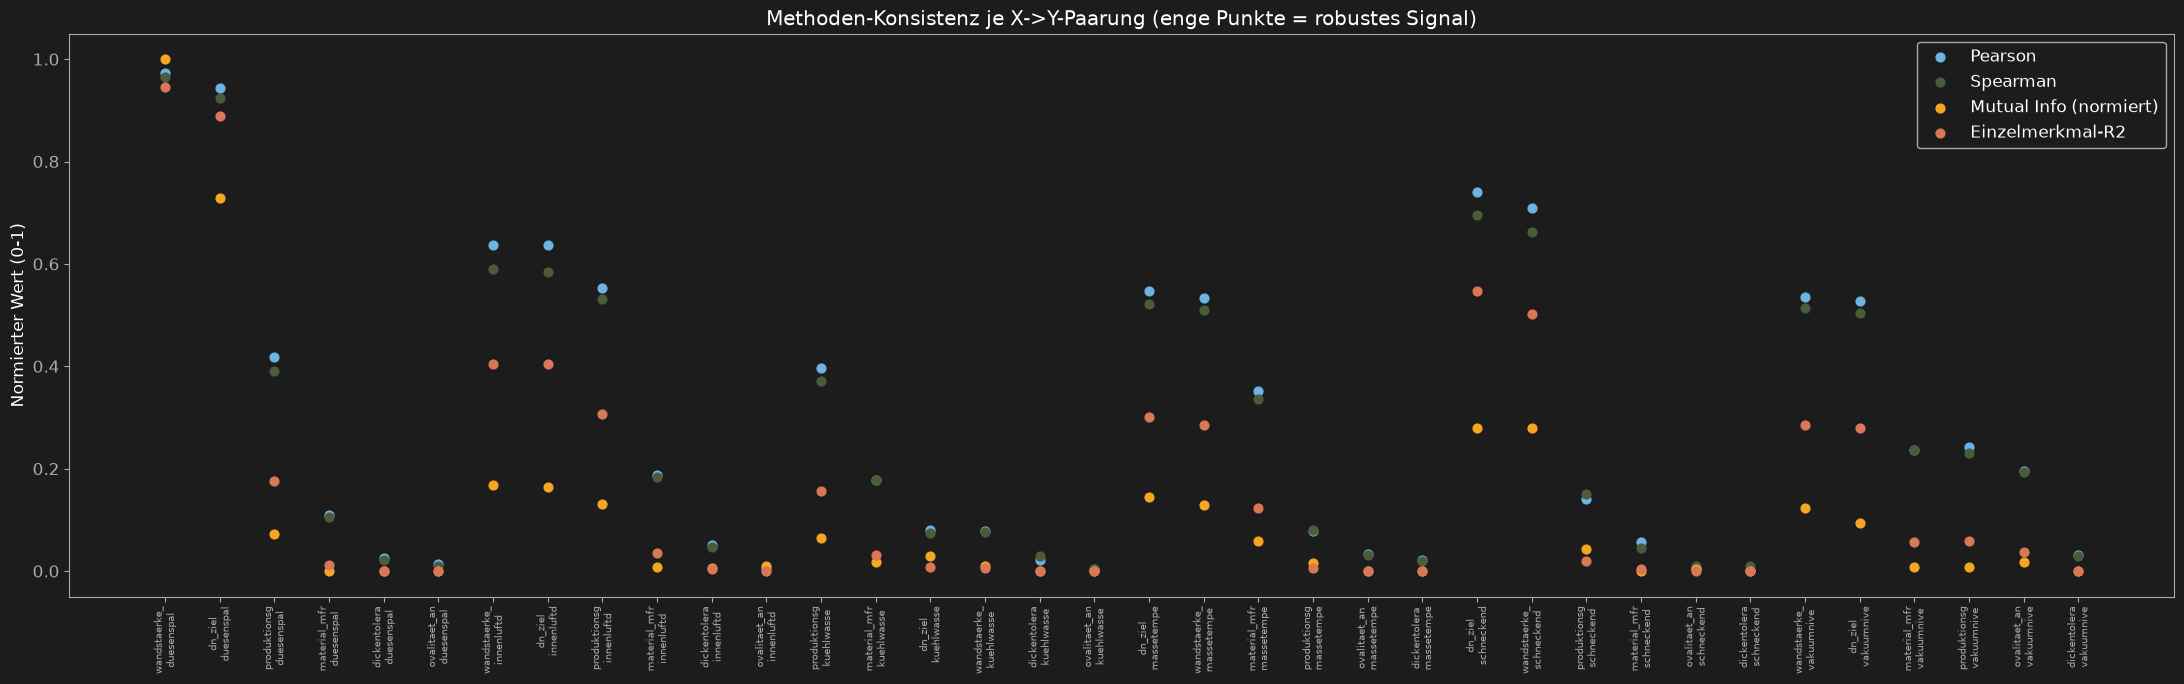

In [24]:
# =============================================================================
# Zelle 22c – Cleveland Dot Plot: Methoden-Konsistenz je X->Y-Paarung
# =============================================================================
# Macht sichtbar, wo die 4 Methoden (Pearson/Spearman/MI/R²) uebereinstimmen
# (enge Punktwolke = robustes Signal) vs. wo sie auseinanderlaufen
# (Hinweis auf Nichtlinearitaet/versteckte Struktur, wie beim alten
# Kalibrierdruck-Sprung). MI wird auf 0-1 normiert (durch Max geteilt),
# um auf derselben Skala wie die anderen drei Methoden vergleichbar zu sein.
# =============================================================================

paarungen = [f"{row['x_merkmal'][:12]}\n{row['y_merkmal'][:10]}" for _, row in zusammenfassung_df.iterrows()]
mi_normiert = zusammenfassung_df["mutual_info"] / zusammenfassung_df["mutual_info"].max()

fig, ax = plt.subplots(figsize=(22, 7))
x_pos = np.arange(len(zusammenfassung_df))

ax.scatter(x_pos, zusammenfassung_df["pearson_abs"], color=COLOR_BLUE, s=40, label="Pearson", zorder=3)
ax.scatter(x_pos, zusammenfassung_df["spearman_abs"], color=COLOR_GREEN, s=40, label="Spearman", zorder=3)
ax.scatter(x_pos, mi_normiert, color=COLOR_GOLD, s=40, label="Mutual Info (normiert)", zorder=3)
ax.scatter(x_pos, zusammenfassung_df["einzelmerkmal_r2"], color="#D97757", s=40, label="Einzelmerkmal-R2", zorder=3)

ax.set_xticks(x_pos)
ax.set_xticklabels(paarungen, rotation=90, fontsize=7)
ax.set_ylabel("Normierter Wert (0-1)")
ax.set_title("Methoden-Konsistenz je X->Y-Paarung (enge Punkte = robustes Signal)")
ax.legend(loc="upper right")
plt.tight_layout()
save_figure(fig, "../reports/figures/09_cleveland_dot_plot_methoden_vergleich.png")
plt.show()

## Notebook 09 – Abschluss: EDA Modell B (AP 3.2b)

### Durchgefuehrte Schritte
| AP | Inhalt | Status |
|---|---|---|
| 0.1-0.2 | Blinde Sichtung, Datenwoerterbuch | Erledigt |
| 1.1-1.6 | Deskriptive Statistik, Verteilungen, IQR-Ausreisser, Kategoriale Variablen | Erledigt |
| 2.1-2.8 | Pearson, Spearman, Mutual Information, Kruskal-Wallis, Boxplots, Einzelmerkmal-R², Feature Importance, X_B-Multikollinearitaet | Erledigt |
| 3 | PCA auf X_B | Erledigt |
| 4 | Ground-Truth-Validierung | Entfaellt (keine kategoriale Zielstruktur mehr vorhanden) |
| 5 | Bayes-Floor je Y_B | Erledigt, mit wichtiger methodischer Einschraenkung dokumentiert |
| 6 | Zusammenfassende Wichtigkeits-Tabelle | Erledigt |

### Zentrale Root-Cause-Korrekturen waehrend dieser Phase

**1) Vakuum/Innenluft-Mechanismus (Notebook 08):** urspruenglicher harter
DN-Schwellenwert fuer Formluft/Vakuum durch fachliches Feedback als
unrealistisch identifiziert - ersetzt durch zwei separate, gleichzeitig
wirkende kontinuierliche Groessen (vakuumniveau, innenluftdruck).
Vollstaendiger EDA-Neustart erforderlich, alle betroffenen Zellen
korrigiert oder entfernt (Ground-Truth-Validierung entfaellt komplett,
da keine binaere Struktur mehr vorhanden).

**2) Ovalitaets-Anforderung fehlte in allen Y_B-Formeln:** EDA deckte
auf, dass ovalitaet_anforderung in keiner Formel verwendet wurde (Signal
ueberall ≈0). Nachtraeglich in vakuumniveau-Formel integriert (fachlich:
engere Toleranz -> praezisere Kalibrierung -> hoeheres Vakuumniveau).
Nach Korrektur: moderates, konsistentes Signal ueber alle vier Methoden
(Rang 4.2 statt 5.6).

### Wichtige methodische Klaerung

**Bayes-Floor "blind" vs. formelbasiert:** kritische Nutzerpruefung deckte
auf, dass die direkte Nutzung der bekannten Generierungsformel dem
Blind-EDA-Prinzip widerspricht. Klargestellt: formelbasierte Berechnung
ist eine interne Konstruktions-Validierung, kein Teil der offiziellen
blinden EDA. State-of-Art-Alternativen dokumentiert (Empirical Upper
Bound, Replicate-Based Noise Estimation, Test-Retest, Residualanalyse) -
der methodisch korrekte Bayes-Floor-Ersatz erfolgt spaeter ueber das
beste erreichte CV-R² in der Modelltrainingsphase.

**Cleveland Dot Plot als Methoden-Konsistenz-Check:** eingefuehrt, um
sichtbar zu machen, wo Pearson/Spearman/Mutual-Information/R²
uebereinstimmen (robustes Signal) vs. auseinanderlaufen (Hinweis auf
nichtlineare/versteckte Struktur). Bestaetigt: mit Ausnahme der jetzt
korrigierten Faelle zeigt der Datensatz durchgehend methodenkonsistente
Signale.

### Zentrale inhaltliche Erkenntnisse

- **Duesenspalt** einzige Y_B-Groesse nahe einer trivialen Lookup-
  Beziehung (R²=0.945 durch wandstaerke_soll allein) - physikalisch
  begruendet (Die-Swell-Kompensation)
- Alle anderen 5 Y_B-Groessen benoetigen mehrere Merkmale gemeinsam -
  echter ML-Mehrwert bestaetigt
- **dn_ziel/wandstaerke_soll** dominante Treiber (durch hohe interne
  Korrelation r=0.957 teilweise redundant, relevant fuer spaetere
  Feature-Set-Entscheidungen)
- **wandtyp** zeigt (wie bei Modell A) kaum eigenstaendigen Effekt -
  konsistentes Muster ueber beide Modelle hinweg

### Bekannte Limitationen
- Bayes-Floor-Werte (formelbasiert) dienen nur als interner Abgleich,
  nicht als offizielle EDA-Aussage - echte Obergrenzen-Schaetzung folgt
  in der Modelltrainingsphase
- dickentoleranz-Effekt (Rauschniveau-Modulation statt Mittelwert-
  Verschiebung) wird von den Standard-Korrelationsmethoden nicht erfasst -
  bekannte methodische Grenze, dokumentiert

### Naechster Schritt
Preprocessing Modell B (Notebook 10): Encoding, Skalierung, Feature
Engineering, sklearn.Pipeline-Grundgerüst - analog zu Notebook 04
(Modell A), mit den heute gewonnenen Erkenntnissen (X_B-Multikollinearität
dn_ziel/wandstaerke_soll, Feature-Set-Ablationsbedarf).

In [ ]:
# =============================================================================
# Zelle 25 – AP: Preprocessing-Implikationen aus EDA-Kennzahlen ableiten
# =============================================================================
# Arbeitsprinzip: Skalierungsempfehlung wird aus den bereits vorhandenen
# EDA-Kennzahlen (Skewness, Kurtosis) begruendet, nicht vorab angenommen.
# =============================================================================

deskriptiv_check = pd.read_csv("../reports/tables/09_deskriptive_statistik_model_b.csv", index_col=0)

def skalierungs_empfehlung(skew, kurt):
    if abs(skew) < 0.5 and abs(kurt) < 1.0:
        return "StandardScaler (nahe symmetrisch, moderate Woelbung)"
    elif abs(skew) >= 0.5:
        return "RobustScaler empfehlenswert pruefen (spuerbare Schiefe, Ausreisser-Risiko)"
    elif kurt < -1.0:
        return "StandardScaler vertretbar (plattgipflig/gleichverteilt-aehnlich, aber keine Ausreisser-Haeufung)"
    else:
        return "StandardScaler vertretbar (Grenzfall, Q-Q-Plot pruefen)"

empfehlungen = []
for merkmal in deskriptiv_check.index:
    skew = deskriptiv_check.loc[merkmal, "skewness"]
    kurt = deskriptiv_check.loc[merkmal, "kurtosis"]
    empfehlungen.append({
        "merkmal": merkmal, "skewness": round(skew, 3), "kurtosis": round(kurt, 3),
        "empfehlung": skalierungs_empfehlung(skew, kurt)
    })

empf_df = pd.DataFrame(empfehlungen)
print(empf_df.to_string(index=False))
empf_df.to_csv("../reports/tables/09_preprocessing_empfehlungen_model_b.csv", index=False)

                        merkmal  skewness  kurtosis                                                                                       empfehlung
                   material_mfr     0.095    -0.266                                             StandardScaler (nahe symmetrisch, moderate Woelbung)
                        dn_ziel     0.935     0.479                       RobustScaler empfehlenswert pruefen (spuerbare Schiefe, Ausreisser-Risiko)
               wandstaerke_soll     0.771     0.208                       RobustScaler empfehlenswert pruefen (spuerbare Schiefe, Ausreisser-Risiko)
                 dickentoleranz    -0.015    -1.203 StandardScaler vertretbar (plattgipflig/gleichverteilt-aehnlich, aber keine Ausreisser-Haeufung)
produktionsgeschwindigkeit_soll    -0.052     0.045                                             StandardScaler (nahe symmetrisch, moderate Woelbung)
          ovalitaet_anforderung    -0.042    -1.245 StandardScaler vertretbar (plattgipflig/gleichverteilt

In [26]:
# =============================================================================
# Zelle 26 – Yeo-Johnson: Skewness/Shapiro Vorher/Nachher (alle 12 Merkmale)
# =============================================================================
# State-of-Art-Messmethode fuer Transformationsbedarf: Skewness und
# Shapiro-p VOR und NACH Yeo-Johnson vergleichen - objektiver Nachweis,
# ob die Transformation tatsaechlich wirkt, statt anzunehmen.
# =============================================================================
from sklearn.preprocessing import PowerTransformer
from scipy.stats import shapiro

alle_numerisch = [c for c in df_b.columns if df_b[c].dtype != "object" and c != "schmelzfestigkeit_proxy"]

pt = PowerTransformer(method="yeo-johnson", standardize=False)
df_b_transformiert = pd.DataFrame(
    pt.fit_transform(df_b[alle_numerisch]), columns=alle_numerisch, index=df_b.index
)

vergleich_transformation = []
for col in alle_numerisch:
    skew_vorher = df_b[col].skew()
    skew_nachher = df_b_transformiert[col].skew()
    p_vorher = shapiro(df_b[col].sample(min(len(df_b), 5000), random_state=SEED))[1]
    p_nachher = shapiro(df_b_transformiert[col].sample(min(len(df_b), 5000), random_state=SEED))[1]
    vergleich_transformation.append({
        "merkmal": col,
        "skewness_vorher": round(skew_vorher, 3), "skewness_nachher": round(skew_nachher, 3),
        "shapiro_p_vorher": round(p_vorher, 5), "shapiro_p_nachher": round(p_nachher, 5),
        "normalverteilt_vorher": p_vorher > 0.05, "normalverteilt_nachher": p_nachher > 0.05,
    })

vergleich_df = pd.DataFrame(vergleich_transformation)
print(vergleich_df.to_string(index=False))
vergleich_df.to_csv("../reports/tables/09_yeojohnson_vorher_nachher_model_b.csv", index=False)

                        merkmal  skewness_vorher  skewness_nachher  shapiro_p_vorher  shapiro_p_nachher  normalverteilt_vorher  normalverteilt_nachher
                   material_mfr            0.095            -0.009           0.00000            0.00000                  False                   False
                        dn_ziel            0.935             0.003           0.00000            0.00000                  False                   False
               wandstaerke_soll            0.771             0.033           0.00000            0.00000                  False                   False
                 dickentoleranz           -0.015            -0.023           0.00000            0.00000                  False                   False
produktionsgeschwindigkeit_soll           -0.052             0.002           0.04067            0.06762                  False                    True
          ovalitaet_anforderung           -0.042            -0.049           0.00000          

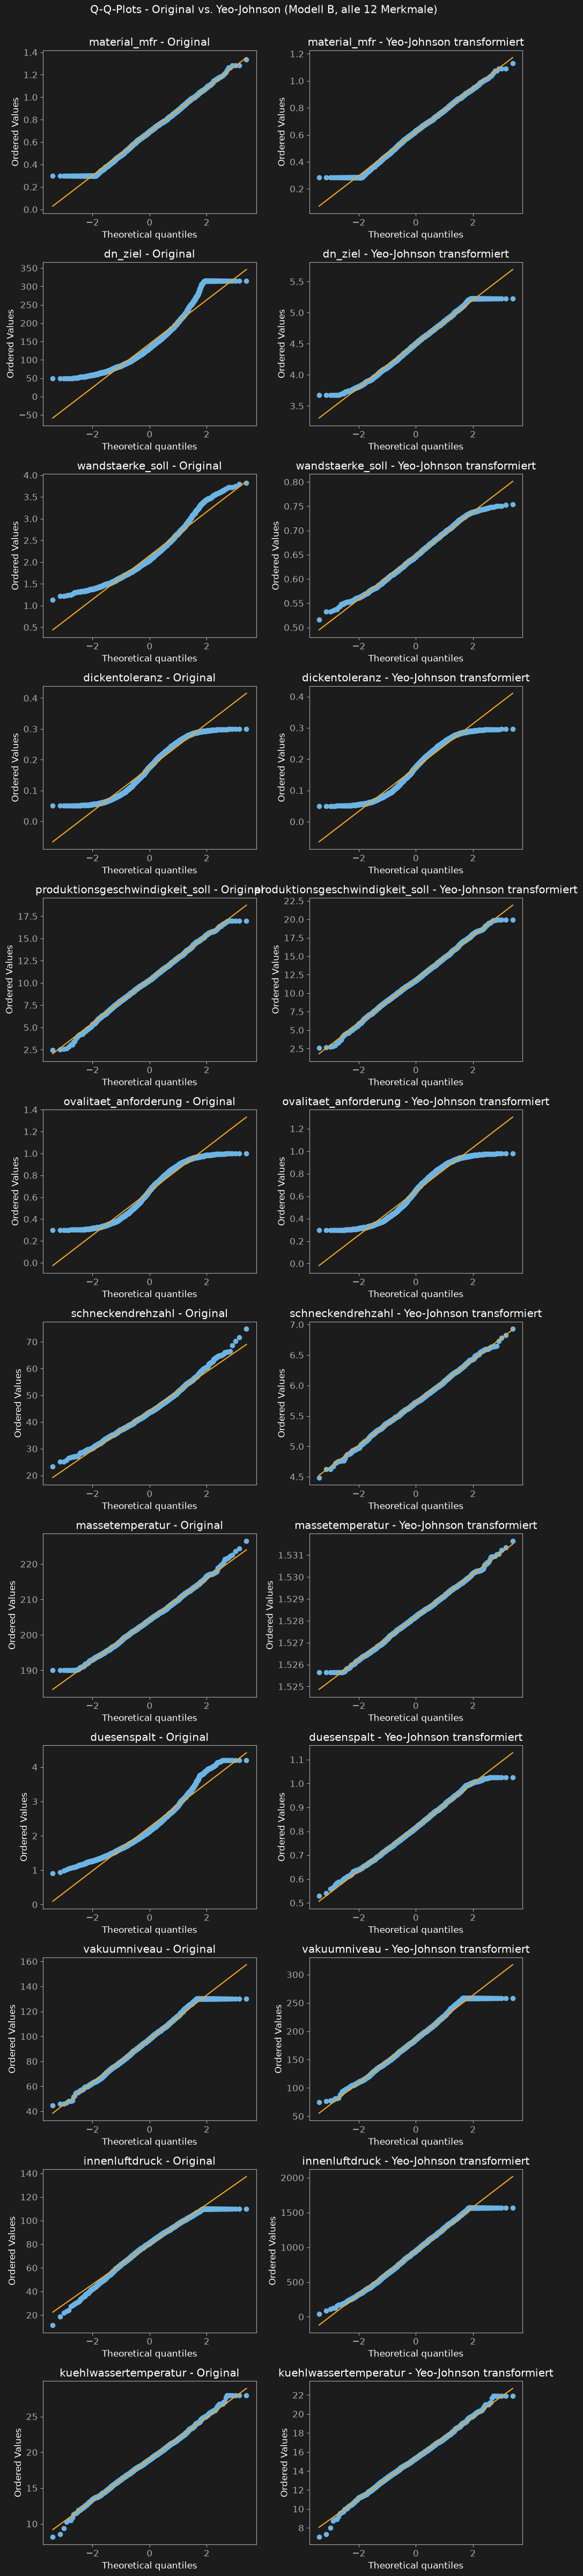

In [27]:
# =============================================================================
# Zelle 27 – Q-Q-Plots: Original vs. Yeo-Johnson (alle 12 Merkmale)
# =============================================================================
# Prueft visuell den Clipping-Verdacht aus Zelle 26: bleibt die
# Nicht-Normalitaet nach Transformation an den Raendern konzentriert
# (Hinweis auf kuenstliche np.clip()-Grenzen aus der Datengenerierung)?
# =============================================================================
fig, axes = plt.subplots(len(alle_numerisch), 2, figsize=(10, 4*len(alle_numerisch)))
fig.suptitle("Q-Q-Plots - Original vs. Yeo-Johnson (Modell B, alle 12 Merkmale)", y=1.001)

for i, col in enumerate(alle_numerisch):
    stats.probplot(df_b[col], dist="norm", plot=axes[i, 0])
    axes[i, 0].set_title(f"{col} - Original")
    axes[i, 0].get_lines()[0].set_markerfacecolor(COLOR_BLUE)
    axes[i, 0].get_lines()[0].set_markeredgecolor(COLOR_BLUE)
    axes[i, 0].get_lines()[1].set_color(COLOR_GOLD)

    stats.probplot(df_b_transformiert[col], dist="norm", plot=axes[i, 1])
    axes[i, 1].set_title(f"{col} - Yeo-Johnson transformiert")
    axes[i, 1].get_lines()[0].set_markerfacecolor(COLOR_BLUE)
    axes[i, 1].get_lines()[0].set_markeredgecolor(COLOR_BLUE)
    axes[i, 1].get_lines()[1].set_color(COLOR_GOLD)

plt.tight_layout()
save_figure(fig, "../reports/figures/09_qq_plots_yeojohnson_model_b.png")
plt.show()

In [28]:
# =============================================================================
# Zelle 28 – Finale Preprocessing-Empfehlung je Merkmal (begruendet aus
# Skewness/Shapiro/Q-Q-Plot-Befunden, Entscheidung liegt beim Nutzer)
# =============================================================================
# Zusammenfuehrung aller bisherigen Befunde (Zelle 02, 26, 27) zu einer
# einzigen, begruendeten Empfehlungstabelle je Merkmal.
# =============================================================================

yeo_johnson_hilfreich = ["dn_ziel", "wandstaerke_soll", "schneckendrehzahl", "innenluftdruck", "vakuumniveau"]

finale_empfehlung = []
for _, row in vergleich_df.iterrows():
    merkmal = row["merkmal"]
    yeo_empfohlen = merkmal in yeo_johnson_hilfreich
    begruendung = (
        "S-Kurve im Q-Q-Plot sichtbar geglaettet, Skewness deutlich reduziert"
        if yeo_empfohlen else
        "kein Unterschied zu Original (bereits symmetrisch/gleichverteilt) oder Verbesserung durch Clipping-Raender ueberdeckt"
    )
    finale_empfehlung.append({
        "merkmal": merkmal,
        "yeo_johnson_empfohlen": yeo_empfohlen,
        "skalierung": "StandardScaler",  # einheitlich, da alle Merkmale nach Clipping keine extremen Ausreisser mehr zeigen (IQR-Analyse Zelle 07 bereits gezeigt)
        "begruendung": begruendung,
        "bekannte_limitation": "kuenstliche np.clip()-Randplateaus aus Notebook 08 - durch keine Transformation behebbar"
    })

finale_empfehlung_df = pd.DataFrame(finale_empfehlung)
print(finale_empfehlung_df.to_string(index=False))
finale_empfehlung_df.to_csv("../reports/tables/09_finale_preprocessing_empfehlung_model_b.csv", index=False)

                        merkmal  yeo_johnson_empfohlen     skalierung                                                                                                           begruendung                                                                      bekannte_limitation
                   material_mfr                  False StandardScaler kein Unterschied zu Original (bereits symmetrisch/gleichverteilt) oder Verbesserung durch Clipping-Raender ueberdeckt kuenstliche np.clip()-Randplateaus aus Notebook 08 - durch keine Transformation behebbar
                        dn_ziel                   True StandardScaler                                                  S-Kurve im Q-Q-Plot sichtbar geglaettet, Skewness deutlich reduziert kuenstliche np.clip()-Randplateaus aus Notebook 08 - durch keine Transformation behebbar
               wandstaerke_soll                   True StandardScaler                                                  S-Kurve im Q-Q-Plot sichtbar geglaettet, Skewness 